In [1]:
import sys

print("Python version:", sys.version)
print("Python executable:", sys.executable)

Python version: 3.13.9 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 19:09:58) [MSC v.1929 64 bit (AMD64)]
Python executable: C:\Users\HP\anaconda3\python.exe


In [2]:
import pandas as pd
import numpy as np
import matplotlib
import seaborn as sns
import sklearn
import imblearn
import joblib

print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("Matplotlib:", matplotlib.__version__)
print("Seaborn:", sns.__version__)
print("Scikit-learn:", sklearn.__version__)
print("Imbalanced-learn:", imblearn.__version__)

Pandas: 2.3.3
NumPy: 2.3.5
Matplotlib: 3.10.6
Seaborn: 0.13.2
Scikit-learn: 1.7.2
Imbalanced-learn: 0.14.0


In [3]:
import joblib
import openpyxl

print("Joblib:", joblib.__version__)
print("Openpyxl:", openpyxl.__version__)

Joblib: 1.5.2
Openpyxl: 3.1.5


# Predicting Company Bankruptcies

## Machine Learning Classification Project

This project focuses on developing a machine learning model to predict whether a company is likely to face bankruptcy based on its financial indicators.

The project covers the complete machine learning workflow, including data understanding, exploratory data analysis, data quality assessment, preprocessing, feature selection, class imbalance handling, model development, model comparison, ensemble modelling, hyperparameter tuning, and final performance evaluation.

## 1. Project Introduction

Company bankruptcy is an important financial risk that can affect lenders, investors, financial institutions, and other stakeholders.

The objective of this project is to use historical financial indicators to develop a binary classification model that can distinguish between companies that are classified as bankrupt and those that are classified as non-bankrupt.

The dataset contains a wide range of financial indicators covering profitability, growth, liquidity, solvency and leverage, efficiency, cash flow, working capital, and other financial measures.

The project will investigate which financial indicators are associated with bankruptcy and evaluate different machine learning algorithms to determine how effectively they classify companies into the two target classes.

## 2. Problem Statement

The main problem addressed in this project is the prediction of company bankruptcy using financial indicators.

Given a set of financial characteristics for a company, the machine learning model will predict whether the company belongs to the bankrupt or non-bankrupt class.

This is a binary classification problem where:

- 0 represents a non-bankrupt company
- 1 represents a bankrupt company

Because bankrupt companies represent a much smaller proportion of the dataset, class imbalance is an important consideration during model development and evaluation.

## 3. Business Objective

The main business objective is to develop a reliable bankruptcy prediction model that can support financial risk assessment.

Potential applications include:

- Identifying companies that may require additional financial assessment.
- Supporting lending and credit-risk analysis.
- Assisting investment and portfolio risk management.
- Helping financial institutions identify potentially high-risk companies.
- Providing data-driven insights into the financial indicators associated with bankruptcy.

The model should be treated as a decision-support tool rather than as the sole basis for financial decisions.

## 4. Project Benefits

The expected benefits of developing a bankruptcy prediction model include:

### Improved Risk Management
The model can help identify companies that may have a higher risk of bankruptcy and allow further investigation or monitoring.

### Better Decision Making
Predictions can provide additional information that may support lending, investment, and financial risk assessment.

### Portfolio Risk Management
Understanding bankruptcy risk can help financial institutions assess the risk profile of companies within their portfolios.

### Financial Indicator Analysis
The project can identify financial indicators that show meaningful relationships with bankruptcy classification.

## 5. Key Questions

This project aims to answer the following questions:

1. Which financial indicators are the most significant predictors of bankruptcy?

2. How does model performance compare across different machine learning algorithms?

3. What are the potential risks and limitations of using the model in real-world decision-making?

## 6. Project Workflow

The project follows the following machine learning workflow:

1. Data Understanding
2. Data Quality Analysis
3. Exploratory Data Analysis
4. Target Variable Analysis
5. Correlation Analysis
6. Feature Selection
7. Train-Test Split
8. Data Preprocessing
9. Class Imbalance Handling
10. Model Development
11. Model Comparison
12. Ensemble Modelling using Voting Classifier
13. Hyperparameter Tuning
14. Final Model Evaluation
15. Feature Importance and Explainability
16. Error Analysis
17. Real-World Risks and Limitations
18. Business Insights and Conclusion

In [4]:
# Import libraries for data analysis
import pandas as pd
import numpy as np

# Import libraries for visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Set visualization style
sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


## 7. Import Libraries

The following Python libraries are used throughout the project:

- **Pandas:** Used for data loading, manipulation, and analysis.
- **NumPy:** Used for numerical operations.
- **Matplotlib:** Used for creating data visualizations.
- **Seaborn:** Used for statistical visualizations and exploratory data analysis.

Display settings are also configured to make it easier to inspect the complete dataset during analysis.

## 8. Load the Dataset

The dataset will be loaded from the CSV file provided for the company bankruptcy prediction project.

The target variable is `Bankrupt?`, which indicates whether a company is classified as bankrupt or non-bankrupt.

In [7]:
# Load the dataset
file_path = "../Data/Bankruptcies.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully.")
print("Shape of the dataset:", df.shape)

Dataset loaded successfully.
Shape of the dataset: (6819, 96)


In [8]:
# Display the first five rows
df.head()

,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,Continuous interest rate (after tax),Operating Expense Rate,Research and development expense rate,Cash flow rate,Interest-bearing debt interest rate,Tax rate (A),Net Value Per Share (B),Net Value Per Share (A),Net Value Per Share (C),Persistent EPS in the Last Four Seasons,Cash Flow Per Share,Revenue Per Share (Yuan ¥),Operating Profit Per Share (Yuan ¥),Per Share Net profit before tax (Yuan ¥),Realized Sales Gross Profit Growth Rate,Operating Profit Growth Rate,After-tax Net Profit Growth Rate,Regular Net Profit Growth Rate,Continuous Net Profit Growth Rate,Total Asset Growth Rate,Net Value Growth Rate,Total Asset Return Growth Rate Ratio,Cash Reinvestment %,Current Ratio,Quick Ratio,Interest Expense Ratio,Total debt/Total net worth,Debt ratio %,Net worth/Assets,Long-term fund suitability ratio (A),Borrowing dependency,Contingent liabilities/Net worth,Operating profit/Paid-in capital,Net profit before tax/Paid-in capital,Inventory and accounts receivable/Net value,Total Asset Turnover,Accounts Receivable Turnover,Average Collection Days,Inventory Turnover Rate (times),Fixed Assets Turnover Frequency,Net Worth Turnover Rate (times),Revenue per person,Operating profit per person,Allocation rate per person,Working Capital to Total Assets,Quick Assets/Total Assets,Current Assets/Total Assets,Cash/Total Assets,Quick Assets/Current Liability,Cash/Current Liability,Current Liability to Assets,Operating Funds to Liability,Inventory/Working Capital,Inventory/Current Liability,Current Liabilities/Liability,Working Capital/Equity,Current Liabilities/Equity,Long-term Liability to Current Assets,Retained Earnings to Total Assets,Total income/Total expense,Total expense/Assets,Current Asset Turnover Rate,Quick Asset Turnover Rate,Working capitcal Turnover Rate,Cash Turnover Rate,Cash Flow to Sales,Fixed Assets to Assets,Current Liability to Liability,Current Liability to Equity,Equity to Long-term Liability,Cash Flow to Total Assets,Cash Flow to Liability,CFO to Assets,Cash Flow to Equity,Current Liability to Current Assets,Liability-Assets Flag,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,1,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,0.780985,1.256969e-04,0.0,0.458143,0.000725,0.0,0.147950,0.147950,0.147950,0.169141,0.311664,0.017560,0.095921,0.138736,0.022102,0.848195,0.688979,0.688979,0.217535,4.980000e+09,0.000327,0.263100,0.363725,0.002259,0.001208,0.629951,0.021266,0.207576,0.792424,0.005024,0.390284,0.006479,0.095885,0.137757,0.398036,0.086957,0.001814,0.003487,1.820926e-04,1.165007e-04,0.032903,0.034164,0.392913,0.037135,0.672775,0.166673,0.190643,0.004094,0.001997,1.473360e-04,0.147308,0.334015,0.276920,0.001036,0.676269,0.721275,0.339077,0.025592,0.903225,0.002022,0.064856,7.010000e+08,6.550000e+09,0.593831,4.580000e+08,0.671568,0.424206,0.676269,0.339077,0.126549,0.637555,0.458609,0.520382,0.312905,0.118250,0,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,1,0.016469
1,1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,0.781506,2.897851e-04,0.0,0.461867,0.000647,0.0,0.182251,0.182251,0.182251,0.208944,0.318137,0.021144,0.093722,0.169918,0.022080,0.848088,0.689693,0.689702,0.217620,6.110000e+09,0.000443,0.264516,0.376709,0.006016,0.004039,0.635172,0.012502,0.171176,0.828824,0.005059,0.376760,0.005835,0.093743,0.168962,0.397725,0.064468,0.001286,0.004917,9.360000e+09,7.190000e+08,0.025484,0.0068

### Initial Dataset Inspection

The first few records are examined to understand the structure of the financial indicators and the target variable.

The dataset contains multiple financial ratios and indicators that will be analyzed to identify patterns associated with company bankruptcy.

In [9]:
# Display dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6819 entries, 0 to 6818
Data columns (total 96 columns):
 #   Column                                                    Non-Null Count  Dtype  
---  ------                                                    --------------  -----  
 0   Bankrupt?                                                 6819 non-null   int64  
 1    ROA(C) before interest and depreciation before interest  6819 non-null   float64
 2    ROA(A) before interest and % after tax                   6819 non-null   float64
 3    ROA(B) before interest and depreciation after tax        6819 non-null   float64
 4    Operating Gross Margin                                   6819 non-null   float64
 5    Realized Sales Gross Margin                              6819 non-null   float64
 6    Operating Profit Rate                                    6819 non-null   float64
 7    Pre-tax net Interest Rate                                6819 non-null   float64
 8    After-tax net Int

## 9. Data Understanding

Before performing exploratory data analysis and machine learning, it is important to understand the structure and characteristics of the dataset.

In this section, we will examine:

- Number of observations and features
- Feature names
- Data types
- Target variable
- Unique values
- Basic statistical characteristics of the dataset

This initial assessment will help identify the nature of the variables and determine the appropriate preprocessing and modelling techniques.

In [10]:
# Check the number of rows and columns
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 6819
Number of columns: 96


In [11]:
# Display all column names
for i, column in enumerate(df.columns, start=1):
    print(f"{i}. {column}")

1. Bankrupt?
2.  ROA(C) before interest and depreciation before interest
3.  ROA(A) before interest and % after tax
4.  ROA(B) before interest and depreciation after tax
5.  Operating Gross Margin
6.  Realized Sales Gross Margin
7.  Operating Profit Rate
8.  Pre-tax net Interest Rate
9.  After-tax net Interest Rate
10.  Non-industry income and expenditure/revenue
11.  Continuous interest rate (after tax)
12.  Operating Expense Rate
13.  Research and development expense rate
14.  Cash flow rate
15.  Interest-bearing debt interest rate
16.  Tax rate (A)
17.  Net Value Per Share (B)
18.  Net Value Per Share (A)
19.  Net Value Per Share (C)
20.  Persistent EPS in the Last Four Seasons
21.  Cash Flow Per Share
22.  Revenue Per Share (Yuan ¥)
23.  Operating Profit Per Share (Yuan ¥)
24.  Per Share Net profit before tax (Yuan ¥)
25.  Realized Sales Gross Profit Growth Rate
26.  Operating Profit Growth Rate
27.  After-tax Net Profit Growth Rate
28.  Regular Net Profit Growth Rate
29.  Continuo

### Feature Overview

The dataset contains 95 financial predictor variables and one target variable, `Bankrupt?`.

The financial variables represent different aspects of company performance, including profitability, growth, liquidity, solvency and leverage, efficiency, cash flow, working capital, and other financial indicators.

The target variable `Bankrupt?` is a binary variable used to identify whether a company is classified as bankrupt or non-bankrupt.

In [12]:
# Check the data type of each column
display(df.dtypes.to_frame(name="Data Type"))

,Data Type
Bankrupt?,int64
ROA(C) before interest and depreciation before interest,float64
ROA(A) before interest and % after tax,float64
ROA(B) before interest and depreciation after tax,float64
Operating Gross Margin,float64
Realized Sales Gross Margin,float64
Operating Profit Rate,float64
Pre-tax net Interest Rate,float64
After-tax net Interest Rate,float64
Non-industry income and expenditure/revenue,float64


In [13]:
# Count the number of columns by data type
display(df.dtypes.value_counts())

float64    93
int64       3
Name: count, dtype: int64

### Target Variable

The target variable for this project is `Bankrupt?`.

It is a binary classification target:

- `0` = Non-bankrupt
- `1` = Bankrupt

Understanding the distribution of these two classes is important because an unequal class distribution can affect the performance of classification models.

In [14]:
# Check unique values in the target variable
print("Unique values in target variable:")
print(df["Bankrupt?"].unique())

print("\nNumber of unique values:")
print(df["Bankrupt?"].nunique())

Unique values in target variable:
[1 0]

Number of unique values:
2


In [15]:
# Count observations in each target class
target_counts = df["Bankrupt?"].value_counts().sort_index()

display(target_counts.to_frame(name="Count"))

,Count
Bankrupt?,
0,6599
1,220


In [16]:
# Calculate percentage distribution of target classes
target_percentage = (
    df["Bankrupt?"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

display(target_percentage.to_frame(name="Percentage"))

,Percentage
Bankrupt?,
0,96.77
1,3.23


### Data Understanding – Initial Findings

The dataset contains 6,819 observations and 96 columns, consisting of 95 financial predictor variables and one binary target variable.

The target variable, `Bankrupt?`, contains two classes: non-bankrupt (0) and bankrupt (1).

The target distribution is highly imbalanced, with approximately 96.77% of observations belonging to the non-bankrupt class and 3.23% belonging to the bankrupt class.

This class imbalance is an important consideration for the subsequent modelling stage. Appropriate techniques will be applied to the training data, while the test set will be kept representative of the original distribution for unbiased evaluation.

## 10. Data Quality Analysis

Before performing detailed exploratory data analysis, it is important to assess the quality and completeness of the dataset.

In this section, we will check for:

- Missing values
- Duplicate observations
- Constant or near-constant features
- Data consistency
- Potentially unusual feature values

These checks help ensure that the dataset is suitable for further analysis and machine learning modelling.

In [17]:
missing_values = df.isnull().sum()

missing_summary = (
    missing_values[missing_values > 0]
    .sort_values(ascending=False)
)

if missing_summary.empty:
    print("No missing values found in the dataset.")
else:
    display(missing_summary.to_frame(name="Missing Values"))

No missing values found in the dataset.


### Missing Value Analysis

The dataset does not contain missing values.

Therefore, no missing-value imputation is required before proceeding with the exploratory analysis and modelling stages.

In [18]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


### Duplicate Row Analysis

No duplicate observations were found in the dataset.

Therefore, no duplicate rows need to be removed before further analysis.

In [20]:
constant_features = [
    column for column in df.columns
    if df[column].nunique() <= 1
]

print("Constant features:")
print(constant_features)

Constant features:
[' Net Income Flag']


### Constant Feature Analysis

Constant features contain the same value for every observation and therefore do not provide useful information for distinguishing between bankrupt and non-bankrupt companies.

Any constant feature identified during this analysis will be excluded from the modelling dataset during the feature preparation stage.

In [21]:
unique_summary = pd.DataFrame({
    "Feature": df.columns,
    "Unique Values": [df[column].nunique() for column in df.columns]
})

display(unique_summary.head(20))

,Feature,Unique Values
0,Bankrupt?,2
1,ROA(C) before interest and depreciation befor...,3333
2,ROA(A) before interest and % after tax,3151
3,ROA(B) before interest and depreciation after...,3160
4,Operating Gross Margin,3781
5,Realized Sales Gross Margin,3788
6,Operating Profit Rate,3376
7,Pre-tax net Interest Rate,3789
8,After-tax net Interest Rate,3604
9,Non-industry income and expenditure/revenue,2551


In [22]:
quality_summary = pd.DataFrame({
    "Metric": [
        "Total Rows",
        "Total Columns",
        "Missing Values",
        "Duplicate Rows",
        "Constant Features"
    ],
    "Value": [
        df.shape[0],
        df.shape[1],
        df.isnull().sum().sum(),
        df.duplicated().sum(),
        len(constant_features)
    ]
})

display(quality_summary)

,Metric,Value
0,Total Rows,6819
1,Total Columns,96
2,Missing Values,0
3,Duplicate Rows,0
4,Constant Features,1


### Data Quality – Initial Findings

The data quality assessment shows that the dataset contains 6,819 observations and 96 columns.

No missing values and no duplicate observations were identified.

A constant feature was identified during the analysis. Since a constant feature does not provide discriminatory information for the classification task, it will be excluded during the feature preparation stage.

Overall, the dataset is structurally suitable for further exploratory data analysis, while the identified feature-quality issue will be addressed before model development.

## 11. Exploratory Data Analysis (EDA)

Exploratory Data Analysis is performed to understand the distribution and characteristics of the financial variables in the dataset.

The analysis will focus on:

- Distribution of the target variable
- Descriptive statistics of financial indicators
- Distribution of selected financial features
- Comparison of financial indicators across bankruptcy classes
- Identification of skewed and unusual values

EDA helps identify important patterns and relationships that can guide feature selection and model development.

### 11.1 Target Variable Distribution

The target variable `Bankrupt?` is examined to understand the proportion of bankrupt and non-bankrupt companies in the dataset.

Because bankruptcy is a relatively rare event in the dataset, the class distribution is expected to be highly imbalanced.

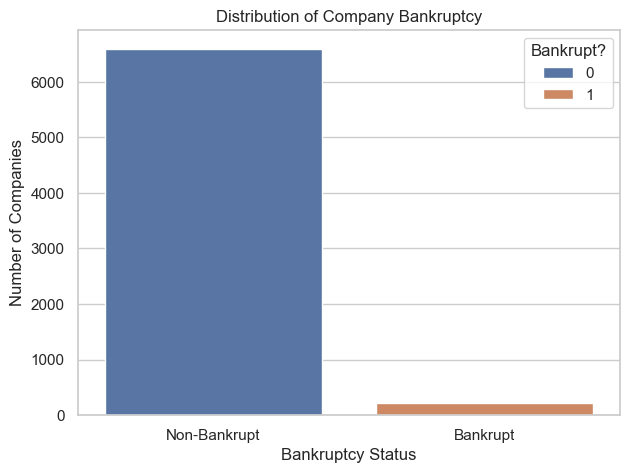

In [23]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Bankrupt?",
    hue="Bankrupt?"
)

plt.title("Distribution of Company Bankruptcy")
plt.xlabel("Bankruptcy Status")
plt.ylabel("Number of Companies")

plt.xticks([0, 1], ["Non-Bankrupt", "Bankrupt"])

plt.show()

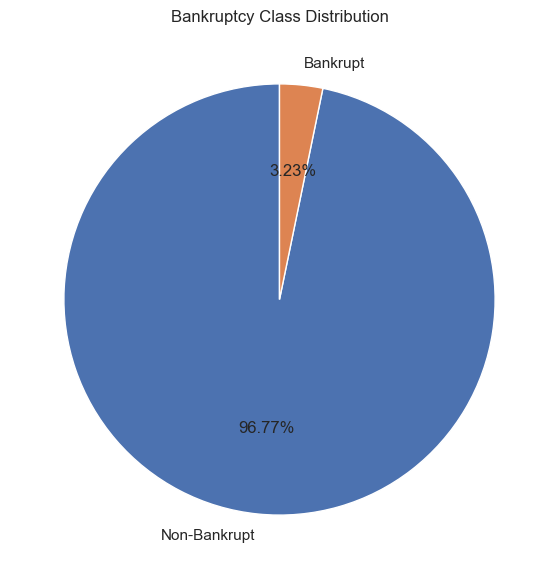

In [24]:
target_counts = df["Bankrupt?"].value_counts().sort_index()

plt.figure(figsize=(7, 7))

plt.pie(
    target_counts,
    labels=["Non-Bankrupt", "Bankrupt"],
    autopct="%1.2f%%",
    startangle=90
)

plt.title("Bankruptcy Class Distribution")

plt.show()

### Target Distribution – Interpretation

The target variable is highly imbalanced.

The majority of companies belong to the non-bankrupt class, while only a small proportion are classified as bankrupt.

This imbalance is important because a model could achieve high overall accuracy by primarily predicting the majority class.

Therefore, model evaluation will not rely on accuracy alone. Precision, recall, F1-score, confusion matrix, and other appropriate classification metrics will also be considered.

### 11.2 Descriptive Statistics

Descriptive statistics are used to understand the central tendency and spread of the financial indicators.

Measures such as mean, standard deviation, minimum, maximum, and quartiles provide an initial understanding of the numerical variables.

In [25]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
Bankrupt?,6819.0,3.226280e-02,1.767102e-01,0.0,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
ROA(C) before interest and depreciation before interest,6819.0,5.051796e-01,6.068564e-02,0.0,4.765271e-01,5.027056e-01,5.355628e-01,1.000000e+00
ROA(A) before interest and % after tax,6819.0,5.586249e-01,6.562003e-02,0.0,5.355430e-01,5.598016e-01,5.891572e-01,1.000000e+00
ROA(B) before interest and depreciation after tax,6819.0,5.535887e-01,6.159481e-02,0.0,5.272766e-01,5.522780e-01,5.841051e-01,1.000000e+00
Operating Gross Margin,6819.0,6.079480e-01,1.693381e-02,0.0,6.004447e-01,6.059975e-01,6.139142e-01,1.000000e+00
Realized Sales Gross Margin,6819.0,6.079295e-01,1.691607e-02,0.0,6.004338e-01,6.059759e-01,6.138421e-01,1.000000e+00
Operating Profit Rate,6819.0,9.987551e-01,1.301003e-02,0.0,9.989692e-01,9.990222e-01,9.990945e-01,1.000000e+00
Pre-tax net Interest Rate,6819.0,7.971898e-01,1.286899e-02,0.0,7.973859e-01,7.974636e-01,7.975788e-01,1.000000e+00
After-tax net Interest Rate,6819.0,8.090836e-01,1.360065e-02,0.0,8.093116e-01,8.093752e-01,8.094693e-01,1.000000e+00
Non-industry income and expenditure/revenue,6819.0,3.036229e-01,1.116344e-02,0.0,3.034663e-01,3.035255e-01,3.035852e-01,1.000000e+00


### Descriptive Statistics – Initial Observations

The descriptive statistics show that the financial indicators have different scales and ranges.

Several variables show substantial differences between their minimum, maximum, and quartile values, indicating that some financial indicators may be highly skewed or contain extreme observations.

These characteristics will be investigated further during the distribution and outlier analysis.

### 11.3 Distribution of Selected Financial Indicators

To understand the behaviour of important financial indicators, their distributions will be visualized.

The selected variables represent different financial dimensions such as profitability, leverage, liquidity, and financial strength.

In [30]:
for column in df.columns:
    if "Debt" in column or "ROA" in column or "Liability" in column or "Net Income" in column:
        print(repr(column))

' ROA(C) before interest and depreciation before interest'
' ROA(A) before interest and % after tax'
' ROA(B) before interest and depreciation after tax'
' Debt ratio %'
' Quick Assets/Current Liability'
' Cash/Current Liability'
' Current Liability to Assets'
' Operating Funds to Liability'
' Inventory/Current Liability'
' Current Liabilities/Liability'
' Long-term Liability to Current Assets'
' Current Liability to Liability'
' Current Liability to Equity'
' Equity to Long-term Liability'
' Cash Flow to Liability'
' Current Liability to Current Assets'
' Liability-Assets Flag'
' Net Income to Total Assets'
" Net Income to Stockholder's Equity"
' Liability to Equity'
' Net Income Flag'
' Equity to Liability'


In [31]:
selected_features = [
    column for column in df.columns
    if (
        "ROA" in column
        or "Debt" in column
        or "Liability" in column
        or "Net Income to Total Assets" in column
    )
]

print("Selected features:")
print(selected_features)

Selected features:
[' ROA(C) before interest and depreciation before interest', ' ROA(A) before interest and % after tax', ' ROA(B) before interest and depreciation after tax', ' Debt ratio %', ' Quick Assets/Current Liability', ' Cash/Current Liability', ' Current Liability to Assets', ' Operating Funds to Liability', ' Inventory/Current Liability', ' Current Liabilities/Liability', ' Long-term Liability to Current Assets', ' Current Liability to Liability', ' Current Liability to Equity', ' Equity to Long-term Liability', ' Cash Flow to Liability', ' Current Liability to Current Assets', ' Liability-Assets Flag', ' Net Income to Total Assets', ' Liability to Equity', ' Equity to Liability']


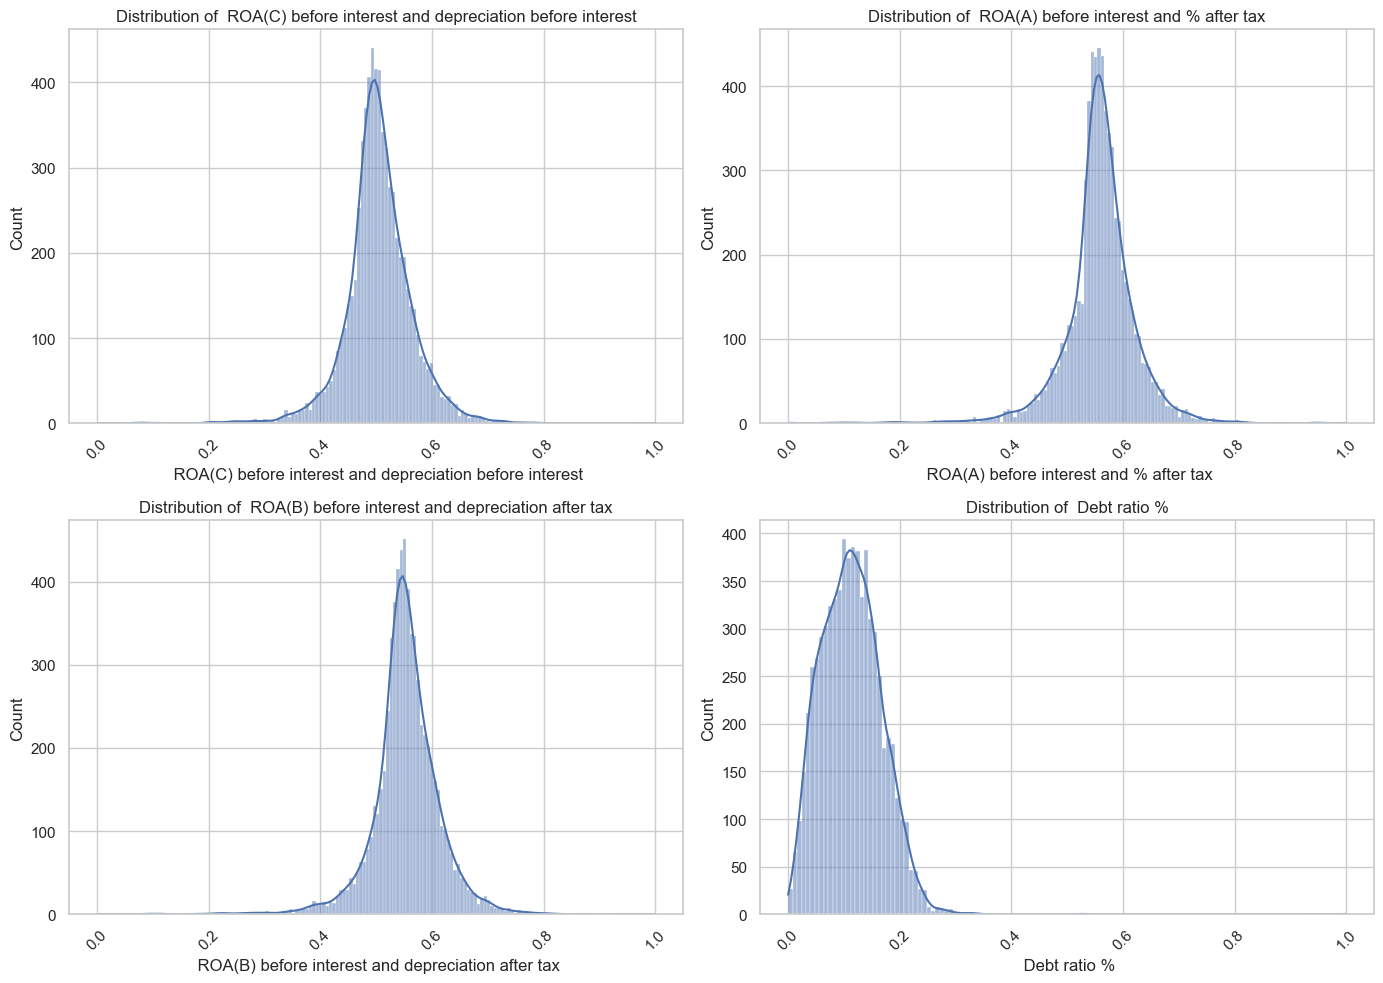

In [32]:
plot_features = selected_features[:4]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, feature in zip(axes.flatten(), plot_features):
    sns.histplot(
        data=df,
        x=feature,
        kde=True,
        ax=ax
    )
    ax.set_title(f"Distribution of {feature}")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

### Distribution Analysis – Initial Findings

The selected financial indicators show different distribution patterns.

Some variables are relatively concentrated, while others show skewness and extreme values.

These differences in scale and distribution are important considerations for subsequent preprocessing and machine learning.

The presence of extreme financial observations will not automatically lead to their removal because such observations may represent genuine financial distress and may contain useful information for bankruptcy prediction.

## 12. Bankruptcy Class-wise Financial Analysis

To better understand the factors associated with company bankruptcy, financial indicators will be compared between bankrupt and non-bankrupt companies.

Comparing the two target classes can help identify financial characteristics that differ between companies classified as bankrupt and those classified as non-bankrupt.

These observations will be used as supporting evidence during feature selection and model interpretation.

### 12.1 Mean Financial Indicators by Bankruptcy Status

The average values of selected financial indicators will be compared across the two bankruptcy classes.

This provides an initial descriptive comparison of the financial characteristics of bankrupt and non-bankrupt companies.

In [33]:
class_means = df.groupby("Bankrupt?")[selected_features].mean().T

class_means.columns = ["Non-Bankrupt", "Bankrupt"]

display(class_means)

,Non-Bankrupt,Bankrupt
ROA(C) before interest and depreciation before interest,5.080693e-01,4.185033e-01
ROA(A) before interest and % after tax,5.620147e-01,4.569468e-01
ROA(B) before interest and depreciation after tax,5.566593e-01,4.614835e-01
Debt ratio %,1.107144e-01,1.870470e-01
Quick Assets/Current Liability,3.712684e+06,5.020996e-03
Cash/Current Liability,2.989953e+07,2.549409e+08
Current Liability to Assets,8.888701e-02,1.442381e-01
Operating Funds to Liability,3.543226e-01,3.389912e-01
Inventory/Current Liability,5.571944e+07,5.842727e+07
Current Liabilities/Liability,7.623841e-01,7.380459e-01


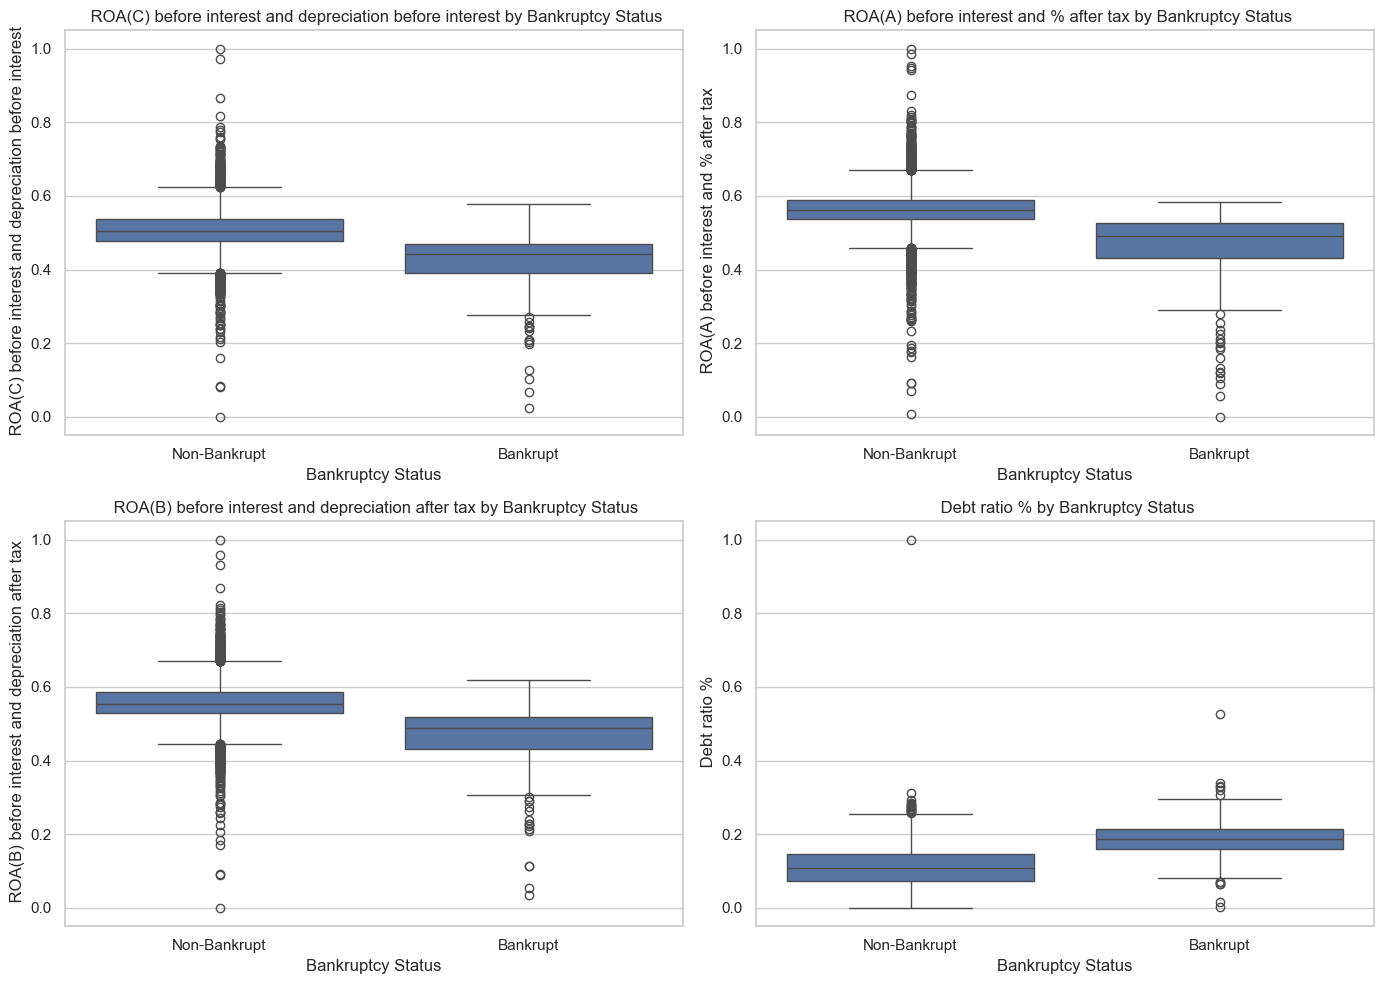

In [34]:
comparison_features = selected_features[:4]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, feature in zip(axes.flatten(), comparison_features):
    sns.boxplot(
        data=df,
        x="Bankrupt?",
        y=feature,
        ax=ax
    )
    
    ax.set_title(f"{feature} by Bankruptcy Status")
    ax.set_xlabel("Bankruptcy Status")
    ax.set_ylabel(feature)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Non-Bankrupt", "Bankrupt"])

plt.tight_layout()
plt.show()

### Boxplot Interpretation

The boxplots provide a visual comparison of the selected financial indicators between bankrupt and non-bankrupt companies.

Differences in the central tendency and spread of the distributions may indicate that certain financial indicators are associated with bankruptcy status.

However, differences observed during EDA represent descriptive relationships and should not be interpreted as proof of causation.

The machine learning models and subsequent feature analysis will be used to evaluate the predictive usefulness of the financial indicators.

### 12.2 Correlation of Financial Indicators with Bankruptcy

Correlation analysis is used to examine the linear relationship between individual financial indicators and the bankruptcy target.

This analysis can help identify variables that have relatively stronger associations with bankruptcy classification.

Correlation values will be treated as an exploratory screening measure rather than as final evidence of predictive importance.

In [35]:
target_correlation = (
    df.corr(numeric_only=True)["Bankrupt?"]
    .drop("Bankrupt?")
    .sort_values(key=abs, ascending=False)
)

display(target_correlation.to_frame(name="Correlation with Bankruptcy"))

,Correlation with Bankruptcy
Net Income to Total Assets,-0.315457
ROA(A) before interest and % after tax,-0.282941
ROA(B) before interest and depreciation after tax,-0.273051
ROA(C) before interest and depreciation before interest,-0.260807
Net worth/Assets,-0.250161
Debt ratio %,0.250161
Persistent EPS in the Last Four Seasons,-0.219560
Retained Earnings to Total Assets,-0.217779
Net profit before tax/Paid-in capital,-0.207857
Per Share Net profit before tax (Yuan ¥),-0.201395


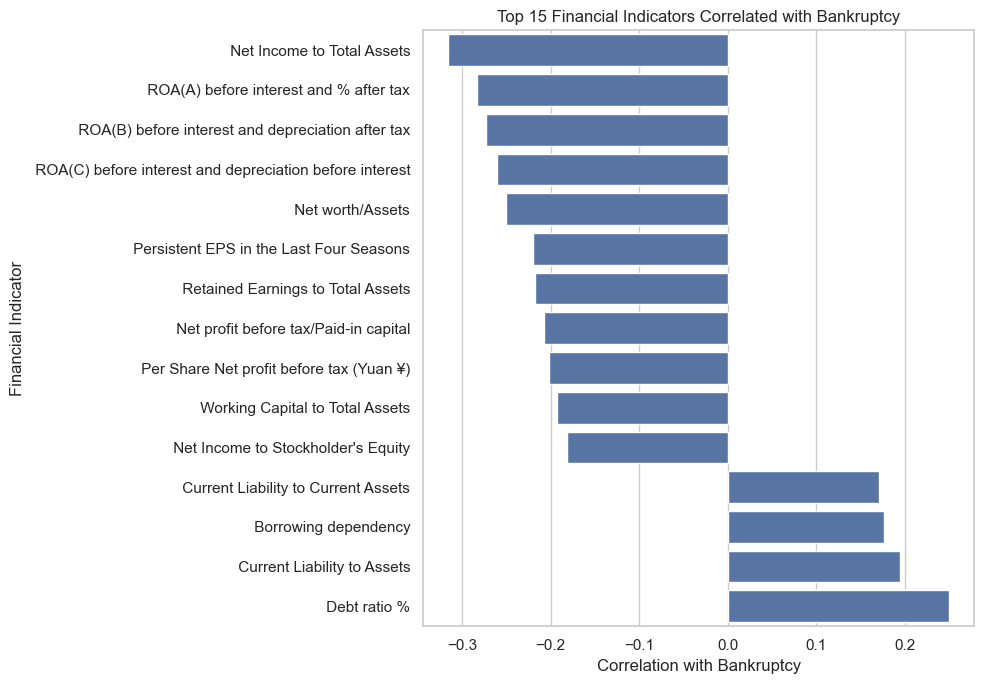

In [36]:
top_correlations = target_correlation.head(15).sort_values()

plt.figure(figsize=(10, 7))

sns.barplot(
    x=top_correlations.values,
    y=top_correlations.index
)

plt.title("Top 15 Financial Indicators Correlated with Bankruptcy")
plt.xlabel("Correlation with Bankruptcy")
plt.ylabel("Financial Indicator")

plt.tight_layout()
plt.show()

### Correlation Analysis – Initial Findings

The correlation analysis indicates that several financial indicators have stronger associations with the bankruptcy target than others.

Indicators related to profitability, financial strength, leverage, and liabilities appear among the variables with relatively stronger correlations.

However, correlation alone does not determine whether a variable is an important machine learning predictor. Some variables may provide useful predictive information through non-linear relationships or interactions with other features.

Therefore, correlation analysis will be used as one component of feature selection, together with multicollinearity analysis and model-based evaluation.

### Important Note on Correlation

A correlation with the bankruptcy target does not imply causation.

In addition, highly correlated predictor variables may contain overlapping information. Including many highly redundant variables can make the model more complex and may affect interpretability.

Therefore, predictor-to-predictor correlation will also be examined before final feature selection.

## 13. Predictor Correlation and Multicollinearity Analysis

Financial indicators can sometimes measure similar aspects of a company's financial condition.

For example, multiple profitability, liquidity, or leverage indicators may contain overlapping information.

Therefore, it is important to examine correlations between predictor variables before developing the machine learning models.

This analysis will help identify highly correlated features and reduce unnecessary redundancy during feature selection.

In [37]:
predictor_df = df.drop(columns=["Bankrupt?"])

correlation_matrix = predictor_df.corr()

display(correlation_matrix.head())

,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,Continuous interest rate (after tax),Operating Expense Rate,Research and development expense rate,Cash flow rate,Interest-bearing debt interest rate,Tax rate (A),Net Value Per Share (B),Net Value Per Share (A),Net Value Per Share (C),Persistent EPS in the Last Four Seasons,Cash Flow Per Share,Revenue Per Share (Yuan ¥),Operating Profit Per Share (Yuan ¥),Per Share Net profit before tax (Yuan ¥),Realized Sales Gross Profit Growth Rate,Operating Profit Growth Rate,After-tax Net Profit Growth Rate,Regular Net Profit Growth Rate,Continuous Net Profit Growth Rate,Total Asset Growth Rate,Net Value Growth Rate,Total Asset Return Growth Rate Ratio,Cash Reinvestment %,Current Ratio,Quick Ratio,Interest Expense Ratio,Total debt/Total net worth,Debt ratio %,Net worth/Assets,Long-term fund suitability ratio (A),Borrowing dependency,Contingent liabilities/Net worth,Operating profit/Paid-in capital,Net profit before tax/Paid-in capital,Inventory and accounts receivable/Net value,Total Asset Turnover,Accounts Receivable Turnover,Average Collection Days,Inventory Turnover Rate (times),Fixed Assets Turnover Frequency,Net Worth Turnover Rate (times),Revenue per person,Operating profit per person,Allocation rate per person,Working Capital to Total Assets,Quick Assets/Total Assets,Current Assets/Total Assets,Cash/Total Assets,Quick Assets/Current Liability,Cash/Current Liability,Current Liability to Assets,Operating Funds to Liability,Inventory/Working Capital,Inventory/Current Liability,Current Liabilities/Liability,Working Capital/Equity,Current Liabilities/Equity,Long-term Liability to Current Assets,Retained Earnings to Total Assets,Total income/Total expense,Total expense/Assets,Current Asset Turnover Rate,Quick Asset Turnover Rate,Working capitcal Turnover Rate,Cash Turnover Rate,Cash Flow to Sales,Fixed Assets to Assets,Current Liability to Liability,Current Liability to Equity,Equity to Long-term Liability,Cash Flow to Total Assets,Cash Flow to Liability,CFO to Assets,Cash Flow to Equity,Current Liability to Current Assets,Liability-Assets Flag,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
ROA(C) before interest and depreciation before interest,1.000000,0.940124,0.986849,0.334719,0.332755,0.035725,0.053419,0.049222,0.020501,0.051328,0.066869,0.106461,0.323482,0.048882,0.250761,0.505580,0.505407,0.505281,0.775006,0.379839,-0.015932,0.687201,0.750564,0.000591,0.036511,0.115083,0.115040,0.025234,0.019635,-0.021930,0.079906,0.296158,0.013196,-0.026336,0.003988,-0.022208,-0.261427,0.261427,0.002967,-0.161671,-0.035729,0.685028,0.753339,-0.109888,0.210622,-0.033947,0.007019,-0.062660,-0.065919,0.022896,-0.014834,0.301996,-0.012543,0.259680,0.181993,0.098820,0.235314,-0.010530,-0.046009,-0.210256,0.388151,-0.004447,0.013330,0.052783,0.103819,-0.142734,0.021508,0.650217,0.023450,-0.296019,0.005716,-0.027280,0.001824,-0.029477,0.011759,-0.009192,0.052783,-0.142734,-0.086535,0.262454,0.159699,0.504311,0.129002,-0.160725,-0.109272,0.887670,-0.071725,0.008135,0.334721,0.274287,-0.143629,-0.016575,0.010573,NaN,0.052416
ROA(A) before interest and % after tax,0.940124,1.000000,0.955741,0.326969,0.324956,0.032053,0.053518,0.049474,0.029649,0.049909,0.075727,0.084334,0.288440,0.050362,0.225897,0.531799,0.531790,0.531821,0.764828,0.326239,-0.011829,0.654253,0.752578,0.003277,0.042208,0.125384,0.125872,0.024887,0.026977,-0.063970,0.081982,0.263615,0.014102,-0.018412,0.005440,-0.010323,-0.259972,0.259972,0.020707,-0.161868,-0.

### 13.1 Correlation Heatmap

A correlation heatmap provides a visual representation of the relationships between financial indicators.

Strong positive or negative correlations between predictor variables may indicate that some features contain overlapping information.

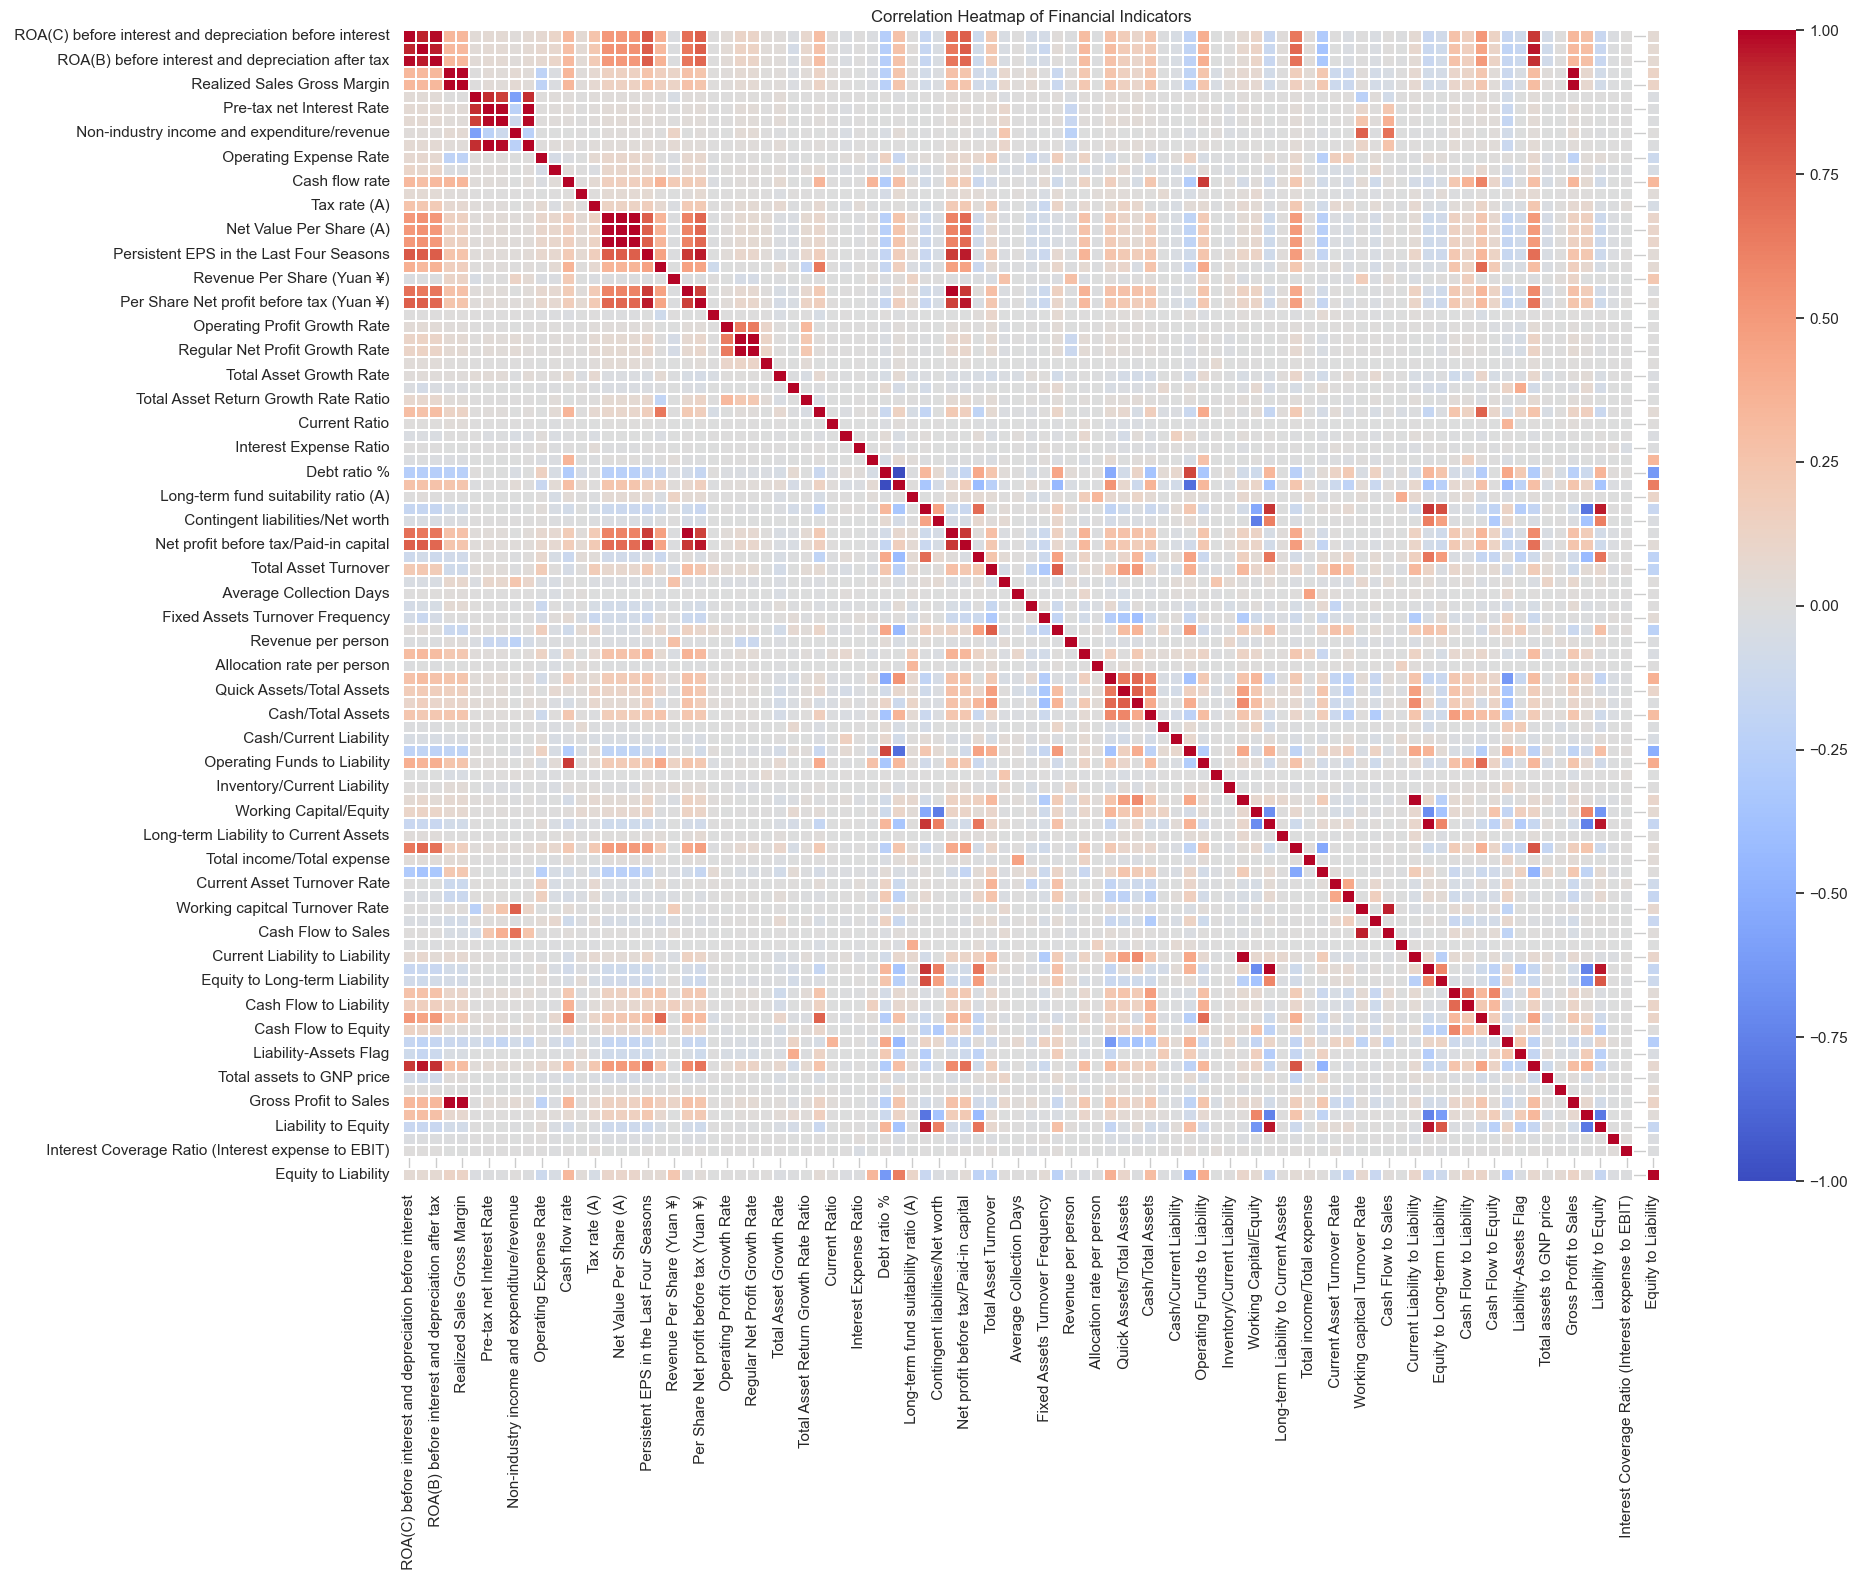

In [38]:
plt.figure(figsize=(20, 16))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
    linewidths=0.1
)

plt.title("Correlation Heatmap of Financial Indicators")
plt.tight_layout()
plt.show()

### 13.2 Identifying Highly Correlated Feature Pairs

To identify potentially redundant predictors, feature pairs with an absolute correlation of 0.90 or higher will be examined.

A high correlation does not automatically mean that one feature must be removed. The information represented by the variables and their relevance to the modelling objective should also be considered.

In [39]:
upper_triangle = correlation_matrix.where(
    np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
)

high_correlation_pairs = (
    upper_triangle
    .stack()
    .reset_index()
)

high_correlation_pairs.columns = [
    "Feature 1",
    "Feature 2",
    "Correlation"
]

high_correlation_pairs["Absolute Correlation"] = (
    high_correlation_pairs["Correlation"].abs()
)

high_correlation_pairs = (
    high_correlation_pairs[
        high_correlation_pairs["Absolute Correlation"] >= 0.90
    ]
    .sort_values("Absolute Correlation", ascending=False)
)

display(high_correlation_pairs)

,Feature 1,Feature 2,Correlation,Absolute Correlation
3976,Current Liabilities/Equity,Current Liability to Equity,1.000000,1.000000
3918,Current Liabilities/Liability,Current Liability to Liability,1.000000,1.000000
2718,Debt ratio %,Net worth/Assets,-1.000000,1.000000
360,Operating Gross Margin,Gross Profit to Sales,1.000000,1.000000
1368,Net Value Per Share (A),Net Value Per Share (C),0.999837,0.999837
276,Operating Gross Margin,Realized Sales Gross Margin,0.999518,0.999518
449,Realized Sales Gross Margin,Gross Profit to Sales,0.999518,0.999518
1290,Net Value Per Share (B),Net Value Per Share (A),0.999342,0.999342
1291,Net Value Per Share (B),Net Value Per Share (C),0.999179,0.999179
1762,Operating Profit Per Share (Yuan ¥),Operating profit/Paid-in capital,0.998696,0.998696


### Highly Correlated Feature Pairs – Interpretation

The analysis identifies pairs of financial indicators with very strong correlations.

These highly correlated variables may contain overlapping information and can contribute to multicollinearity.

The identified pairs will be considered during feature selection. However, features will not be removed solely based on correlation without considering their financial meaning and predictive relevance.

### 13.3 Removing Non-Informative Features

The data quality analysis identified constant features that contain the same value for every observation.

Since such features cannot help distinguish between bankrupt and non-bankrupt companies, they will be excluded from the modelling feature set.

In [40]:
features_for_modeling = df.drop(columns=["Bankrupt?"] + constant_features)

print("Original number of predictors:", df.shape[1] - 1)
print("Number of constant features removed:", len(constant_features))
print("Predictors available for modelling:", features_for_modeling.shape[1])

Original number of predictors: 95
Number of constant features removed: 1
Predictors available for modelling: 94


### Feature Preparation – Initial Findings

The predictor correlation analysis identified several highly correlated financial-indicator pairs.

These relationships indicate potential redundancy among some predictors.

The constant feature identified during data quality analysis has been excluded from the modelling feature set.

Further feature selection will consider correlation with the target, predictor redundancy, and model-based importance before the final modelling dataset is created.

## 14. Feature Selection

Feature selection is an important step in the machine learning workflow because the dataset contains a relatively large number of financial indicators.

The objective is to identify informative predictors while reducing unnecessary redundancy.

Feature selection in this project will consider:

- Correlation with the bankruptcy target
- Redundancy between predictor variables
- Removal of non-informative constant features
- Model-based feature importance during later stages

Feature selection will be performed using the training data to avoid information leakage from the test set.

### 14.1 Preparing Predictor and Target Variables

The target variable `Bankrupt?` will be separated from the financial predictors.

The target will be used as the classification label, while the remaining variables will serve as candidate predictors.

In [41]:
X = df.drop(columns=["Bankrupt?"] + constant_features)
y = df["Bankrupt?"]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (6819, 94)
Target shape: (6819,)


### 14.2 Train-Test Split

The dataset will be divided into training and testing subsets.

A stratified split will be used so that the proportion of bankrupt and non-bankrupt companies is approximately preserved in both subsets.

The test set will remain untouched during feature selection and model training so that it can provide an unbiased evaluation of the final models.

In [42]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True).sort_index())

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True).sort_index())

Training set shape: (5455, 94)
Testing set shape: (1364, 94)

Training target distribution:
Bankrupt?
0    0.967736
1    0.032264
Name: proportion, dtype: float64

Testing target distribution:
Bankrupt?
0    0.967742
1    0.032258
Name: proportion, dtype: float64


### 14.3 Target Correlation on Training Data

To reduce the risk of data leakage, correlation-based feature screening will be performed using the training dataset rather than the complete dataset.

The absolute correlation with the bankruptcy target will be examined to identify variables with relatively stronger linear associations.

In [43]:
train_correlation = (
    X_train.assign(**{"Bankrupt?": y_train})
    .corr()["Bankrupt?"]
    .drop("Bankrupt?")
    .sort_values(key=abs, ascending=False)
)

display(
    train_correlation.head(20).to_frame(
        name="Training Correlation with Bankruptcy"
    )
)

,Training Correlation with Bankruptcy
Net Income to Total Assets,-0.316354
ROA(A) before interest and % after tax,-0.283811
ROA(B) before interest and depreciation after tax,-0.275219
ROA(C) before interest and depreciation before interest,-0.262665
Net worth/Assets,-0.247642
Debt ratio %,0.247642
Persistent EPS in the Last Four Seasons,-0.221009
Retained Earnings to Total Assets,-0.213839
Net Income to Stockholder's Equity,-0.206648
Net profit before tax/Paid-in capital,-0.206277


### 14.4 Removing Highly Redundant Predictors

Highly correlated predictor variables may provide overlapping information.

To reduce redundancy, one feature from a pair of predictors with an absolute correlation of 0.90 or higher will be considered for removal.

The correlation threshold is used as a screening rule rather than as a statement that one financial indicator is inherently more important than another.

In [44]:
train_corr_matrix = X_train.corr()

upper_triangle = train_corr_matrix.where(
    np.triu(np.ones(train_corr_matrix.shape), k=1).astype(bool)
)

high_corr_features = [
    column
    for column in upper_triangle.columns
    if any(upper_triangle[column].abs() >= 0.90)
]

print("Number of highly redundant features identified:", len(high_corr_features))
print("\nFeatures considered for removal:")
print(high_corr_features)

Number of highly redundant features identified: 21

Features considered for removal:
[' ROA(A) before interest and % after tax', ' ROA(B) before interest and depreciation after tax', ' Realized Sales Gross Margin', ' Pre-tax net Interest Rate', ' After-tax net Interest Rate', ' Continuous interest rate (after tax)', ' Net Value Per Share (A)', ' Net Value Per Share (C)', ' Per Share Net profit before tax (Yuan ¥)', ' Regular Net Profit Growth Rate', ' Total Asset Return Growth Rate Ratio', ' Net worth/Assets', ' Operating profit/Paid-in capital', ' Net profit before tax/Paid-in capital', ' Working capitcal Turnover Rate', ' Cash Flow to Sales', ' Current Liability to Liability', ' Current Liability to Equity', ' Net Income to Total Assets', ' Gross Profit to Sales', ' Liability to Equity']


In [45]:
X_train_selected = X_train.drop(columns=high_corr_features)
X_test_selected = X_test.drop(columns=high_corr_features)

print("Original training features:", X_train.shape[1])
print("Selected training features:", X_train_selected.shape[1])
print("Original testing features:", X_test.shape[1])
print("Selected testing features:", X_test_selected.shape[1])

Original training features: 94
Selected training features: 73
Original testing features: 94
Selected testing features: 73


### Feature Selection – Initial Findings

The feature-selection process removed the constant feature identified during data-quality analysis and screened highly correlated predictor variables for redundancy.

The remaining predictors provide the candidate feature set for model development.

Feature selection will not be considered complete based only on correlation. Model-based feature importance and predictive performance will also be examined during the modelling stage.

The test dataset remains separated and will only be used for final model evaluation.

## 15. Class Imbalance Handling

The bankruptcy dataset contains substantially fewer bankrupt companies than non-bankrupt companies.

This class imbalance can cause a classification model to favour the majority class and achieve high accuracy while performing poorly on the minority class.

Since identifying bankrupt companies is an important objective of this project, the minority class must be handled appropriately.

In this project, Random Under-Sampling will be applied to the training data only.

The original test set will remain unchanged so that final model performance can be evaluated on a dataset that represents the original class distribution.

### 15.1 Class Distribution Before Resampling

The class distribution of the training data will be examined before applying under-sampling.

In [46]:
print("Training class distribution before resampling:")

before_resampling = y_train.value_counts().sort_index()

display(
    before_resampling.to_frame(name="Count")
)

print("\nClass percentages:")

display(
    (y_train.value_counts(normalize=True)
     .sort_index()
     .mul(100)
     .round(2)
     .to_frame(name="Percentage"))
)

Training class distribution before resampling:


,Count
Bankrupt?,
0,5279
1,176



Class percentages:


,Percentage
Bankrupt?,
0,96.77
1,3.23


### 15.2 Random Under-Sampling

Random under-sampling reduces the number of observations in the majority class so that the classes become more balanced.

The sampling operation will be applied only to the training dataset.

The test dataset will not be resampled because it should represent the original real-world class distribution for final evaluation.

In [47]:
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(
    random_state=42
)

X_train_resampled, y_train_resampled = rus.fit_resample(
    X_train_selected,
    y_train
)

print("Original training set:", X_train_selected.shape)
print("Resampled training set:", X_train_resampled.shape)

print("\nClass distribution after resampling:")

display(
    y_train_resampled.value_counts()
    .sort_index()
    .to_frame(name="Count")
)

Original training set: (5455, 73)
Resampled training set: (352, 73)

Class distribution after resampling:


,Count
Bankrupt?,
0,176
1,176


In [48]:
resampled_percentage = (
    y_train_resampled
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

display(
    resampled_percentage.to_frame(
        name="Percentage"
    )
)

,Percentage
Bankrupt?,
0,50.0
1,50.0


### Class Distribution After Resampling

After random under-sampling, the training data contains a balanced representation of bankrupt and non-bankrupt companies.

This allows the classification algorithms to receive a more balanced training signal and reduces the tendency to favour the majority class.

Importantly, only the training data was resampled. The test data retains the original class distribution and will be used later for unbiased evaluation.

### 15.3 Class Distribution Before and After Resampling

The class distributions before and after under-sampling are visualized to clearly demonstrate the effect of the resampling procedure.

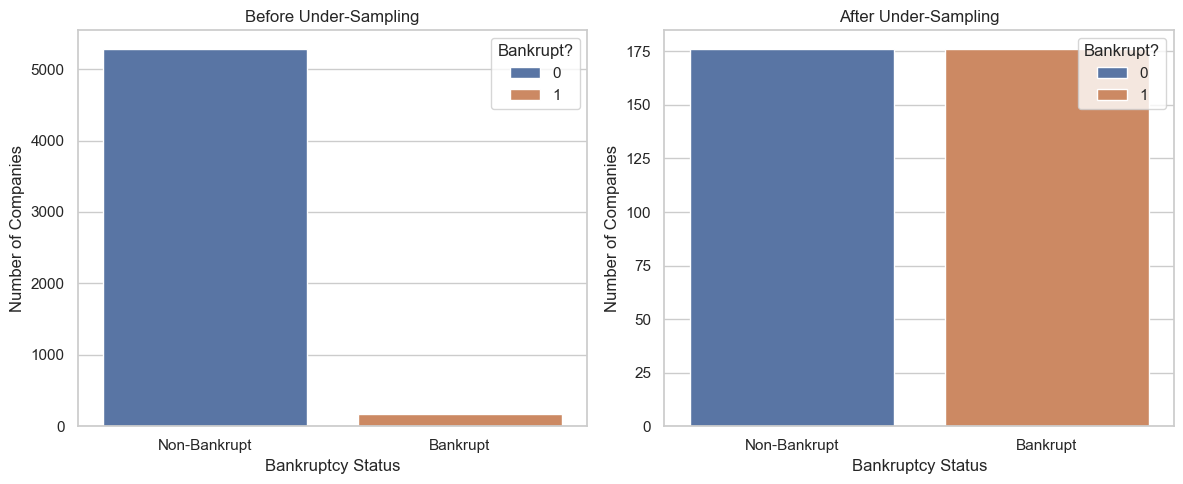

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(
    x=y_train,
    ax=axes[0],
    hue=y_train
)

axes[0].set_title("Before Under-Sampling")
axes[0].set_xlabel("Bankruptcy Status")
axes[0].set_ylabel("Number of Companies")
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(["Non-Bankrupt", "Bankrupt"])

sns.countplot(
    x=y_train_resampled,
    ax=axes[1],
    hue=y_train_resampled
)

axes[1].set_title("After Under-Sampling")
axes[1].set_xlabel("Bankruptcy Status")
axes[1].set_ylabel("Number of Companies")
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(["Non-Bankrupt", "Bankrupt"])

plt.tight_layout()
plt.show()

### Resampling Interpretation

The visualization shows the substantial class imbalance present in the original training data and the balanced class distribution after random under-sampling.

Under-sampling helps provide a more balanced training dataset, but it also removes some majority-class observations.

Therefore, the final model evaluation will be performed using the untouched test set, and multiple classification metrics will be considered rather than accuracy alone.

### Class Imbalance Handling – Final Decision

Random under-sampling has been selected as the primary class-imbalance technique for this project.

The resampling procedure is applied only to the training data to prevent information leakage and preserve a representative test set.

The resulting balanced training dataset will be used for the initial classification models.

Model performance will be evaluated using accuracy, precision, recall, F1-score, and confusion matrix, with particular attention to the model's ability to identify the minority bankruptcy class.

## 16. Machine Learning Model Development

The prepared training dataset will now be used to develop classification models for predicting company bankruptcy.

Multiple machine learning algorithms will be evaluated to compare their predictive performance.

The initial models selected for comparison are:

- Logistic Regression
- Decision Tree
- Random Forest
- Gradient Boosting

These algorithms represent different modelling approaches, including linear classification, tree-based classification, ensemble learning, and boosting.

The models will be evaluated using the same test dataset and consistent classification metrics.

### 16.1 Evaluation Metrics

Because the target variable is highly imbalanced, accuracy alone is not sufficient for evaluating bankruptcy prediction models.

The following metrics will be considered:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

Recall is particularly important because it measures the proportion of actual bankrupt companies that are correctly identified by the model.

In [50]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

print("Machine learning libraries imported successfully.")

Machine learning libraries imported successfully.


### 16.2 Logistic Regression

Logistic Regression is used as a baseline classification model.

It estimates the probability that an observation belongs to the bankruptcy class based on the available financial indicators.

In [51]:
logistic_model = LogisticRegression(
    max_iter=2000,
    random_state=42
)

logistic_model.fit(
    X_train_resampled,
    y_train_resampled
)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


### 16.3 Decision Tree

A Decision Tree is a rule-based model that recursively divides observations using financial indicators.

It can capture non-linear relationships and is relatively easy to interpret.

In [52]:
decision_tree_model = DecisionTreeClassifier(
    random_state=42
)

decision_tree_model.fit(
    X_train_resampled,
    y_train_resampled
)

print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


### 16.4 Random Forest

Random Forest is an ensemble learning algorithm that combines multiple decision trees.

It can capture complex and non-linear relationships and is generally less dependent on a single decision tree than an individual tree model.

In [53]:
random_forest_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

random_forest_model.fit(
    X_train_resampled,
    y_train_resampled
)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


### 16.5 Gradient Boosting

Gradient Boosting builds an ensemble of weak learners sequentially, with each new learner attempting to improve the errors made by previous learners.

This approach can model complex relationships between financial indicators and bankruptcy classification.

In [54]:
gradient_boosting_model = GradientBoostingClassifier(
    random_state=42
)

gradient_boosting_model.fit(
    X_train_resampled,
    y_train_resampled
)

print("Gradient Boosting model trained successfully.")

Gradient Boosting model trained successfully.


### Initial Model Training

Four classification algorithms have now been trained using the balanced training dataset:

1. Logistic Regression
2. Decision Tree
3. Random Forest
4. Gradient Boosting

The models will next be evaluated on the untouched test dataset.

Using the same test set for every model ensures that their performance can be compared consistently.

## 17. Model Evaluation and Comparison

The trained classification models will now be evaluated using the untouched test dataset.

Since the dataset is highly imbalanced, multiple evaluation metrics will be used to obtain a more complete understanding of model performance.

The evaluation metrics include:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

In particular, recall for the bankruptcy class is important because it measures how many of the companies actually classified as bankrupt were correctly identified by the model.

In [55]:
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    return {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-Score": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    }

print("Evaluation function created successfully.")

Evaluation function created successfully.


### 17.1 Evaluating Individual Models

Each trained model will be evaluated on the same untouched test dataset.

Using a common evaluation procedure ensures that the reported metrics are directly comparable across algorithms.

In [56]:
models = {
    "Logistic Regression": logistic_model,
    "Decision Tree": decision_tree_model,
    "Random Forest": random_forest_model,
    "Gradient Boosting": gradient_boosting_model
}

results = []

for model_name, model in models.items():
    metrics = evaluate_model(
        model,
        X_test_selected,
        y_test
    )

    metrics["Model"] = model_name
    results.append(metrics)

results_df = pd.DataFrame(results)

results_df = results_df[
    [
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ]
]

display(results_df.round(4))

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.6935,0.0483,0.4545,0.0873,0.6395
1,Decision Tree,0.8152,0.1176,0.7273,0.2025,0.7727
2,Random Forest,0.8710,0.1827,0.8636,0.3016,0.9455
3,Gradient Boosting,0.8710,0.1827,0.8636,0.3016,0.9453


### Model Comparison – Initial Findings

The evaluation results show differences in classification performance across the four machine learning algorithms.

Because bankruptcy is the minority class, recall, precision, and F1-score provide important information beyond overall accuracy.

The results will be considered together rather than selecting a model based on a single metric.

Further analysis, ensemble modelling, and hyperparameter optimization will be performed before reaching the final modelling stage.

### 17.2 Confusion Matrix Analysis

A confusion matrix provides a detailed view of the classification outcomes.

For this project:

- True Negative (TN): Non-bankrupt company correctly classified as non-bankrupt
- False Positive (FP): Non-bankrupt company incorrectly classified as bankrupt
- False Negative (FN): Bankrupt company incorrectly classified as non-bankrupt
- True Positive (TP): Bankrupt company correctly classified as bankrupt

False negatives are particularly important to examine because they represent bankrupt companies that were not identified by the model.

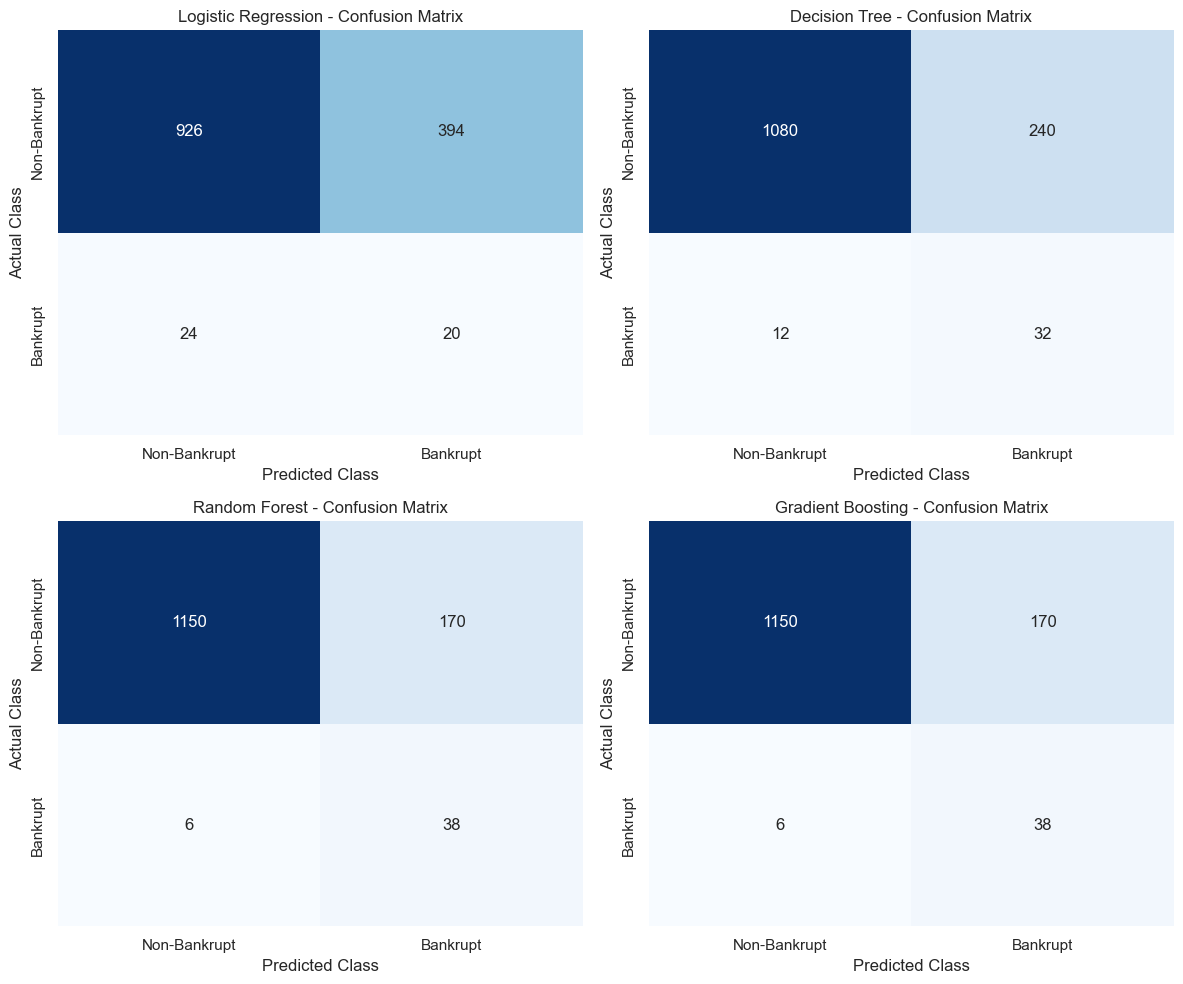

In [57]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, (model_name, model) in zip(axes.flatten(), models.items()):
    y_pred = model.predict(X_test_selected)

    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        ax=ax
    )

    ax.set_title(f"{model_name} - Confusion Matrix")
    ax.set_xlabel("Predicted Class")
    ax.set_ylabel("Actual Class")
    ax.set_xticklabels(["Non-Bankrupt", "Bankrupt"])
    ax.set_yticklabels(["Non-Bankrupt", "Bankrupt"])

plt.tight_layout()
plt.show()

### Confusion Matrix Interpretation

The confusion matrices show how each model classifies bankrupt and non-bankrupt companies.

Particular attention should be given to the false-negative count, because a false negative represents a bankrupt company that was incorrectly classified as non-bankrupt.

The confusion matrices therefore provide additional information that cannot be obtained from accuracy alone.

### 17.3 Detailed Classification Reports

Classification reports provide precision, recall, and F1-score separately for each target class.

This allows the performance of the minority bankruptcy class to be examined directly.

In [58]:
for model_name, model in models.items():
    y_pred = model.predict(X_test_selected)

    print("=" * 70)
    print(model_name)
    print("=" * 70)

    print(
        classification_report(
            y_test,
            y_pred,
            target_names=["Non-Bankrupt", "Bankrupt"],
            zero_division=0
        )
    )

Logistic Regression
              precision    recall  f1-score   support

Non-Bankrupt       0.97      0.70      0.82      1320
    Bankrupt       0.05      0.45      0.09        44

    accuracy                           0.69      1364
   macro avg       0.51      0.58      0.45      1364
weighted avg       0.94      0.69      0.79      1364

Decision Tree
              precision    recall  f1-score   support

Non-Bankrupt       0.99      0.82      0.90      1320
    Bankrupt       0.12      0.73      0.20        44

    accuracy                           0.82      1364
   macro avg       0.55      0.77      0.55      1364
weighted avg       0.96      0.82      0.87      1364

Random Forest
              precision    recall  f1-score   support

Non-Bankrupt       0.99      0.87      0.93      1320
    Bankrupt       0.18      0.86      0.30        44

    accuracy                           0.87      1364
   macro avg       0.59      0.87      0.62      1364
weighted avg       0.97   

### Initial Model Evaluation Summary

The initial model evaluation provides a baseline comparison of the four classification algorithms.

The results demonstrate that different algorithms can produce different balances between precision, recall, and overall predictive performance.

No final model will be selected solely from these initial results. Voting-based ensemble modelling and hyperparameter optimization will be performed in subsequent stages.

The final model selection will consider the complete evaluation results, particularly the model's ability to identify the bankruptcy class while maintaining reasonable overall performance.

## 18. Ensemble Modelling – Voting Classifier

Ensemble learning combines predictions from multiple machine learning models.

A Voting Classifier will be implemented to combine the predictions of different classification algorithms.

The purpose is to examine whether combining multiple models provides a different or improved balance of classification performance compared with individual models.

The ensemble model will be evaluated using the same untouched test dataset used for the individual models.

### 18.1 Hard Voting

Hard voting combines the predicted class labels from multiple classifiers.

Each classifier contributes one predicted class, and the final prediction is determined by the majority vote.

In [59]:
from sklearn.ensemble import VotingClassifier

voting_classifier = VotingClassifier(
    estimators=[
        ("logistic", LogisticRegression(max_iter=2000, random_state=42)),
        ("decision_tree", DecisionTreeClassifier(random_state=42)),
        ("random_forest", RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        )),
        ("gradient_boosting", GradientBoostingClassifier(
            random_state=42
        ))
    ],
    voting="hard"
)

voting_classifier.fit(
    X_train_resampled,
    y_train_resampled
)

print("Hard Voting Classifier trained successfully.")

Hard Voting Classifier trained successfully.


### 18.2 Evaluating the Voting Classifier

The hard voting classifier will be evaluated on the same untouched test dataset.

Its performance will be compared with the individual classification models.

In [60]:
voting_pred = voting_classifier.predict(X_test_selected)

voting_accuracy = accuracy_score(y_test, voting_pred)
voting_precision = precision_score(
    y_test,
    voting_pred,
    zero_division=0
)
voting_recall = recall_score(
    y_test,
    voting_pred,
    zero_division=0
)
voting_f1 = f1_score(
    y_test,
    voting_pred,
    zero_division=0
)

voting_results = pd.DataFrame({
    "Model": ["Hard Voting Classifier"],
    "Accuracy": [voting_accuracy],
    "Precision": [voting_precision],
    "Recall": [voting_recall],
    "F1-Score": [voting_f1]
})

display(voting_results.round(4))

,Model,Accuracy,Precision,Recall,F1-Score
0,Hard Voting Classifier,0.893,0.1964,0.75,0.3113


### 18.3 Voting Classifier Confusion Matrix

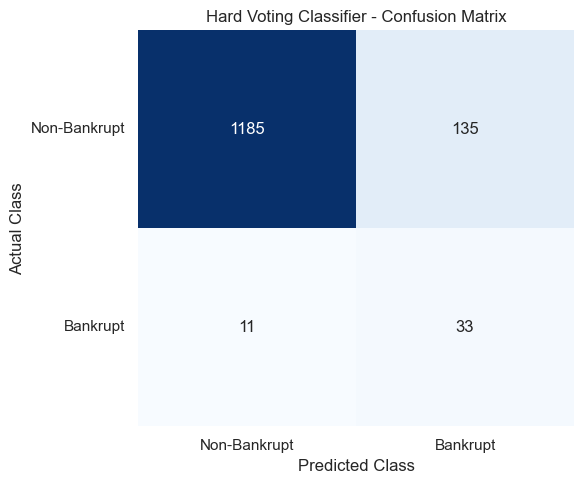

In [61]:
voting_cm = confusion_matrix(
    y_test,
    voting_pred
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    voting_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False
)

plt.title("Hard Voting Classifier - Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.xticks(
    [0.5, 1.5],
    ["Non-Bankrupt", "Bankrupt"]
)

plt.yticks(
    [0.5, 1.5],
    ["Non-Bankrupt", "Bankrupt"],
    rotation=0
)

plt.tight_layout()
plt.show()

### 18.4 Soft Voting

Soft voting combines the predicted probabilities from multiple classifiers.

Instead of using only the predicted class labels, the probability estimates from the individual models are averaged to determine the final prediction.

This approach will be examined to determine whether probability-based ensemble predictions provide useful performance for the bankruptcy classification task.

In [62]:
soft_voting_classifier = VotingClassifier(
    estimators=[
        ("logistic", LogisticRegression(max_iter=2000, random_state=42)),
        ("decision_tree", DecisionTreeClassifier(random_state=42)),
        ("random_forest", RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        )),
        ("gradient_boosting", GradientBoostingClassifier(
            random_state=42
        ))
    ],
    voting="soft"
)

soft_voting_classifier.fit(
    X_train_resampled,
    y_train_resampled
)

print("Soft Voting Classifier trained successfully.")

Soft Voting Classifier trained successfully.


In [63]:
soft_pred = soft_voting_classifier.predict(X_test_selected)
soft_prob = soft_voting_classifier.predict_proba(X_test_selected)[:, 1]

soft_voting_results = pd.DataFrame({
    "Model": ["Soft Voting Classifier"],
    "Accuracy": [
        accuracy_score(y_test, soft_pred)
    ],
    "Precision": [
        precision_score(y_test, soft_pred, zero_division=0)
    ],
    "Recall": [
        recall_score(y_test, soft_pred, zero_division=0)
    ],
    "F1-Score": [
        f1_score(y_test, soft_pred, zero_division=0)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, soft_prob)
    ]
})

display(soft_voting_results.round(4))

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Soft Voting Classifier,0.8548,0.1562,0.7955,0.2612,0.9256


### Ensemble Modelling – Initial Findings

Both hard and soft voting approaches were implemented to combine the predictions of multiple classification algorithms.

The ensemble results will be considered alongside the individual model results.

The voting classifier provides an additional modelling approach, but its performance should be evaluated using the same classification metrics and test dataset rather than assuming that an ensemble will always outperform an individual model.

Hyperparameter optimization will be performed in the next stage to further investigate whether model performance can be improved.

## 19. Hyperparameter Optimization

Machine learning algorithms contain hyperparameters that control how the models learn from the training data.

Hyperparameter optimization will be performed to identify suitable parameter combinations for selected classification algorithms.

Cross-validation will be used during the tuning process to evaluate parameter combinations across multiple training-validation splits.

The test dataset will remain untouched during hyperparameter optimization and will only be used for final evaluation.

### 19.1 Hyperparameter Tuning Strategy

Grid Search with cross-validation will be used for hyperparameter optimization.

The following models will be tuned:

- Logistic Regression
- Decision Tree
- Random Forest
- Gradient Boosting

Because the training dataset has been balanced using under-sampling, the resampled training data will be used during the tuning process.

In [64]:
from sklearn.model_selection import GridSearchCV

print("GridSearchCV imported successfully.")

GridSearchCV imported successfully.


In [65]:
logistic_param_grid = {
    "C": [0.01, 0.1, 1, 10],
    "solver": ["liblinear"],
    "class_weight": [None]
}

logistic_grid = GridSearchCV(
    estimator=LogisticRegression(
        max_iter=2000,
        random_state=42
    ),
    param_grid=logistic_param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

logistic_grid.fit(
    X_train_resampled,
    y_train_resampled
)

print("Best Logistic Regression parameters:")
print(logistic_grid.best_params_)

print("\nBest cross-validation F1-score:")
print(round(logistic_grid.best_score_, 4))

Best Logistic Regression parameters:
{'C': 0.01, 'class_weight': None, 'solver': 'liblinear'}

Best cross-validation F1-score:
0.5087


In [66]:
decision_tree_param_grid = {
    "max_depth": [3, 5, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5]
}

decision_tree_grid = GridSearchCV(
    estimator=DecisionTreeClassifier(
        random_state=42
    ),
    param_grid=decision_tree_param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

decision_tree_grid.fit(
    X_train_resampled,
    y_train_resampled
)

print("Best Decision Tree parameters:")
print(decision_tree_grid.best_params_)

print("\nBest cross-validation F1-score:")
print(round(decision_tree_grid.best_score_, 4))

Best Decision Tree parameters:
{'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 10}

Best cross-validation F1-score:
0.7928


In [67]:
random_forest_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

random_forest_grid = GridSearchCV(
    estimator=RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ),
    param_grid=random_forest_param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

random_forest_grid.fit(
    X_train_resampled,
    y_train_resampled
)

print("Best Random Forest parameters:")
print(random_forest_grid.best_params_)

print("\nBest cross-validation F1-score:")
print(round(random_forest_grid.best_score_, 4))

Best Random Forest parameters:
{'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}

Best cross-validation F1-score:
0.8752


In [68]:
gradient_boosting_param_grid = {
    "n_estimators": [50, 100, 150],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [2, 3, 5]
}

gradient_boosting_grid = GridSearchCV(
    estimator=GradientBoostingClassifier(
        random_state=42
    ),
    param_grid=gradient_boosting_param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

gradient_boosting_grid.fit(
    X_train_resampled,
    y_train_resampled
)

print("Best Gradient Boosting parameters:")
print(gradient_boosting_grid.best_params_)

print("\nBest cross-validation F1-score:")
print(round(gradient_boosting_grid.best_score_, 4))

Best Gradient Boosting parameters:
{'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 150}

Best cross-validation F1-score:
0.8749


### 19.2 Best Hyperparameters

The Grid Search procedure identifies the hyperparameter combination that produced the highest cross-validation F1-score for each model.

The best parameter combinations will be used to create the tuned models for final evaluation.

In [69]:
best_models = {
    "Tuned Logistic Regression": logistic_grid.best_estimator_,
    "Tuned Decision Tree": decision_tree_grid.best_estimator_,
    "Tuned Random Forest": random_forest_grid.best_estimator_,
    "Tuned Gradient Boosting": gradient_boosting_grid.best_estimator_
}

for model_name, model in best_models.items():
    print(model_name)
    print(model)
    print("-" * 70)

Tuned Logistic Regression
LogisticRegression(C=0.01, max_iter=2000, random_state=42, solver='liblinear')
----------------------------------------------------------------------
Tuned Decision Tree
DecisionTreeClassifier(max_depth=5, min_samples_split=10, random_state=42)
----------------------------------------------------------------------
Tuned Random Forest
RandomForestClassifier(min_samples_leaf=2, n_jobs=-1, random_state=42)
----------------------------------------------------------------------
Tuned Gradient Boosting
GradientBoostingClassifier(max_depth=2, n_estimators=150, random_state=42)
----------------------------------------------------------------------


### 19.3 Cross-Validation Results

The best cross-validation F1-score obtained during hyperparameter optimization will be compared across the tuned models.

Cross-validation performance is used during model development, while the untouched test dataset will be reserved for final evaluation.

In [70]:
tuning_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Best CV F1-Score": [
        logistic_grid.best_score_,
        decision_tree_grid.best_score_,
        random_forest_grid.best_score_,
        gradient_boosting_grid.best_score_
    ]
})

display(
    tuning_results.sort_values(
        "Best CV F1-Score",
        ascending=False
    ).round(4)
)

,Model,Best CV F1-Score
2,Random Forest,0.8752
3,Gradient Boosting,0.8749
1,Decision Tree,0.7928
0,Logistic Regression,0.5087


### Hyperparameter Optimization – Interpretation

Hyperparameter optimization provides a systematic approach for identifying suitable model configurations.

The cross-validation F1-score provides an estimate of how well each tuned model performs across different validation subsets of the training data.

However, cross-validation results should not be treated as final test performance. The tuned models must still be evaluated on the untouched test dataset.

### Important Reproducibility Note

The hyperparameter search space, cross-validation strategy, scoring metric, and random state are explicitly defined so that the tuning process can be reproduced.

The final test set is not used during hyperparameter optimization.

This separation helps reduce the risk of overfitting the model-selection process to the test data.

## 20. Evaluation of Tuned Models

The best hyperparameter configurations identified through cross-validation will now be evaluated on the untouched test dataset.

The same evaluation metrics used for the initial models will be calculated, including:

- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC

This allows us to compare the tuned models with their corresponding baseline models.

In [71]:
tuned_results = []

for model_name, model in best_models.items():
    metrics = evaluate_model(model, X_test_selected, y_test)
    metrics["Model"] = model_name
    tuned_results.append(metrics)

tuned_results_df = pd.DataFrame(tuned_results)

tuned_results_df = tuned_results_df[
    ["Model", "Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]
]

display(tuned_results_df.round(4))

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Tuned Logistic Regression,0.6957,0.0487,0.4545,0.0879,0.6408
1,Tuned Decision Tree,0.8541,0.1556,0.7955,0.2602,0.8550
2,Tuned Random Forest,0.8724,0.1845,0.8636,0.3040,0.9451
3,Tuned Gradient Boosting,0.8607,0.1741,0.8864,0.2910,0.9447


### Tuned Model Performance

The tuned models are evaluated using the same test dataset used for the baseline models.

F1-Score and Recall are particularly important because the bankruptcy class is highly imbalanced and correctly identifying bankrupt companies is an important objective.

### Baseline vs Tuned Model Comparison

The performance of the original baseline models will be compared with the corresponding hyperparameter-tuned models.

This comparison helps determine whether hyperparameter optimization produced a meaningful improvement in model performance.

In [72]:
baseline_results = results_df.copy()

comparison_df = pd.concat(
    [baseline_results, tuned_results_df],
    ignore_index=True
)

display(comparison_df.round(4))

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.6935,0.0483,0.4545,0.0873,0.6395
1,Decision Tree,0.8152,0.1176,0.7273,0.2025,0.7727
2,Random Forest,0.8710,0.1827,0.8636,0.3016,0.9455
3,Gradient Boosting,0.8710,0.1827,0.8636,0.3016,0.9453
4,Tuned Logistic Regression,0.6957,0.0487,0.4545,0.0879,0.6408
5,Tuned Decision Tree,0.8541,0.1556,0.7955,0.2602,0.8550
6,Tuned Random Forest,0.8724,0.1845,0.8636,0.3040,0.9451
7,Tuned Gradient Boosting,0.8607,0.1741,0.8864,0.2910,0.9447


### Comparing Precision, Recall and F1-Score

Because the dataset contains a relatively small proportion of bankrupt companies, precision, recall and F1-score provide more informative insights than accuracy alone.

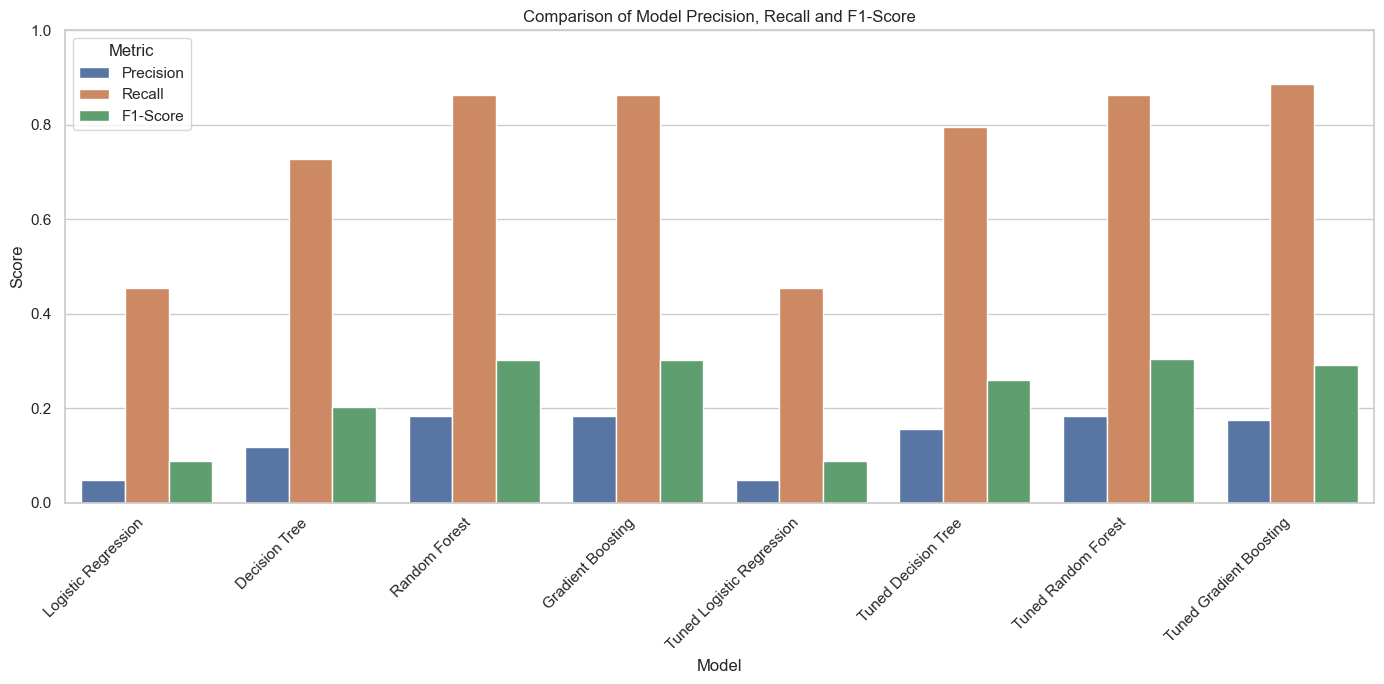

In [73]:
comparison_plot = comparison_df.melt(
    id_vars="Model",
    value_vars=["Precision", "Recall", "F1-Score"],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(14, 7))

sns.barplot(
    data=comparison_plot,
    x="Model",
    y="Score",
    hue="Metric"
)

plt.title("Comparison of Model Precision, Recall and F1-Score")
plt.xlabel("Model")
plt.ylabel("Score")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

### Interpretation of Tuned Model Performance

The comparison above shows how hyperparameter optimization affected the classification performance of the different machine learning models.

The changes in precision, recall and F1-score should be considered together rather than relying on accuracy alone.

A model with higher recall may identify more bankrupt companies, while a model with higher precision may produce fewer false bankruptcy predictions. The F1-score provides a balance between precision and recall.

## 21. Confusion Matrix Analysis for Tuned Models

Confusion matrices provide a detailed view of the classification errors made by each tuned model.

The four outcomes are:

- True Negative: Correctly classified non-bankrupt company
- False Positive: Non-bankrupt company incorrectly classified as bankrupt
- False Negative: Bankrupt company incorrectly classified as non-bankrupt
- True Positive: Correctly classified bankrupt company

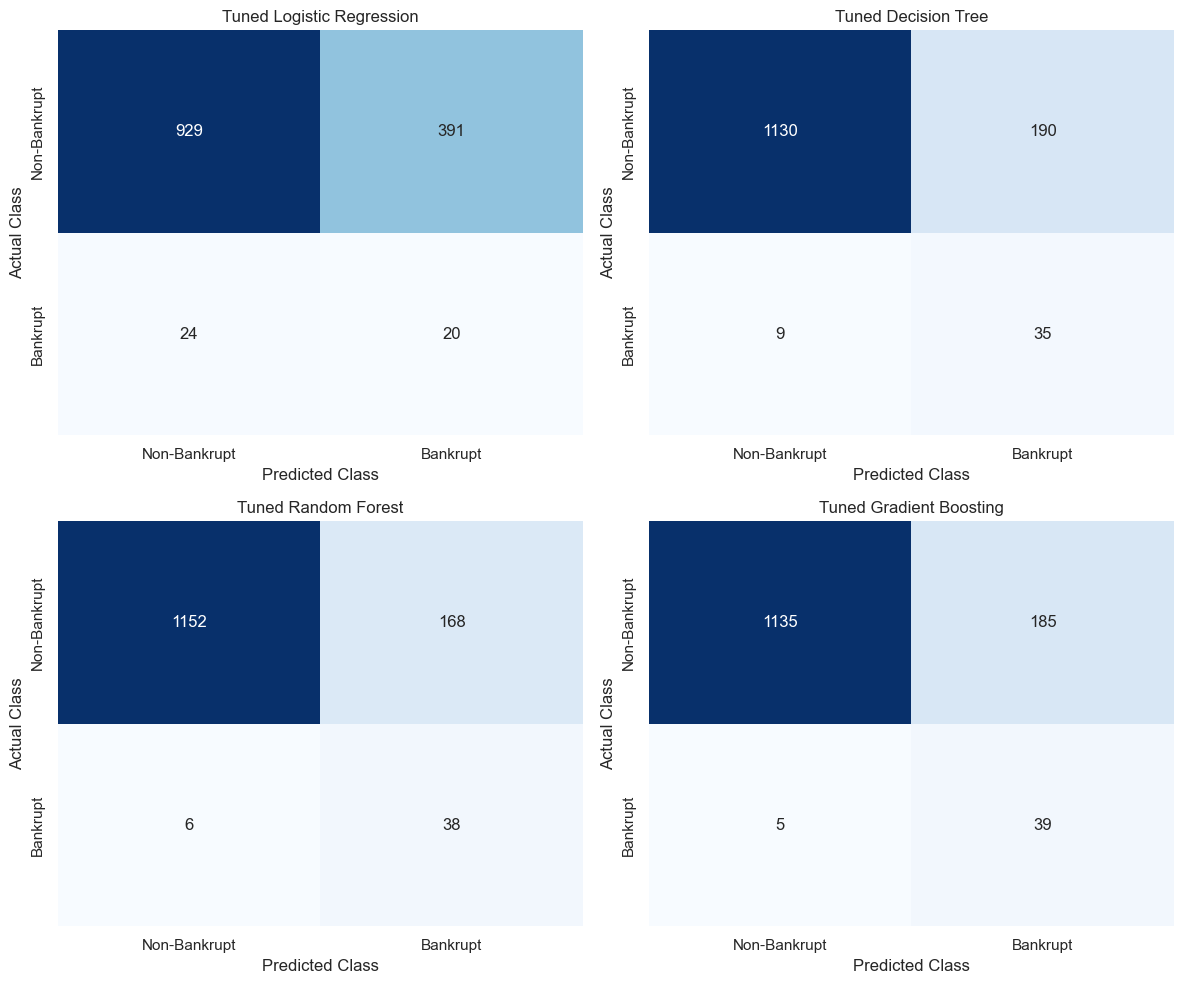

In [74]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, (model_name, model) in zip(axes.flatten(), best_models.items()):
    y_pred = model.predict(X_test_selected)
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        ax=ax
    )

    ax.set_title(model_name)
    ax.set_xlabel("Predicted Class")
    ax.set_ylabel("Actual Class")
    ax.set_xticklabels(["Non-Bankrupt", "Bankrupt"])
    ax.set_yticklabels(["Non-Bankrupt", "Bankrupt"])

plt.tight_layout()
plt.show()

### Confusion Matrix Interpretation

The confusion matrices show how many companies were correctly and incorrectly classified into the two bankruptcy categories.

Particular attention should be given to false negatives because these represent bankrupt companies that were classified as non-bankrupt.

False positives are also important because they represent non-bankrupt companies that were incorrectly identified as bankrupt.

The relative importance of these errors depends on the specific financial application and decision-making context.

### Evaluation Summary

Hyperparameter optimization provides an opportunity to improve the classification performance of the initial models.

The final model selection will consider cross-validation performance, test-set metrics, confusion matrix results, and the business importance of correctly identifying bankrupt companies.

No single metric should be considered in isolation.

## 22. Feature Importance and Explainability

Understanding which financial indicators contribute most to bankruptcy prediction is important for both model interpretation and financial risk analysis.

Tree-based models such as Random Forest and Gradient Boosting provide feature importance measures that can be used to identify the variables that contribute most to the model's predictions.

Feature importance should be interpreted as a model-specific measure and should not be treated as proof of a causal relationship with bankruptcy.

### Random Forest Feature Importance

The tuned Random Forest model will be used to examine the relative importance of the selected financial indicators.

Higher feature importance indicates that the feature contributed more to the model's decision-making process within the trained Random Forest model.

In [75]:
rf_tuned_model = best_models["Tuned Random Forest"]

rf_importance = pd.DataFrame({
    "Feature": X_train_selected.columns,
    "Importance": rf_tuned_model.feature_importances_
})

rf_importance = rf_importance.sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)

display(rf_importance.head(20))

,Feature,Importance
0,Persistent EPS in the Last Four Seasons,0.071131
1,Net Income to Stockholder's Equity,0.064704
2,Borrowing dependency,0.062557
3,Total debt/Total net worth,0.054036
4,Equity to Liability,0.053992
5,Total income/Total expense,0.044890
6,Non-industry income and expenditure/revenue,0.037434
7,Net Value Per Share (B),0.036374
8,ROA(C) before interest and depreciation befor...,0.034496
9,Retained Earnings to Total Assets,0.034351


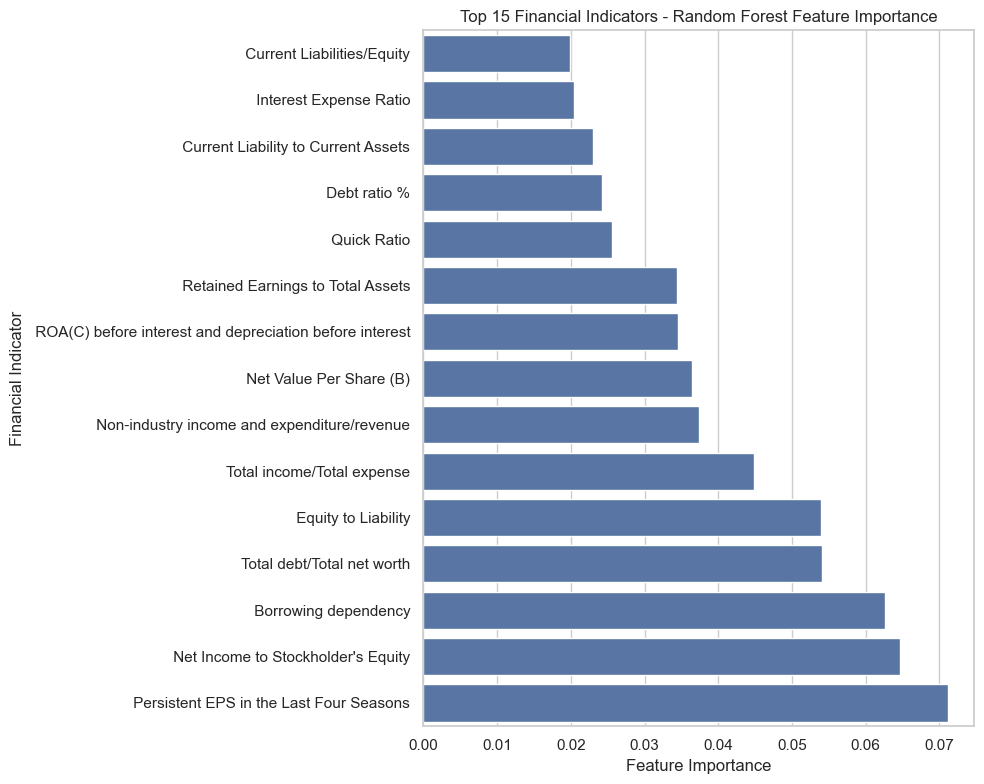

In [76]:
top_rf_features = rf_importance.head(15).sort_values(
    "Importance",
    ascending=True
)

plt.figure(figsize=(10, 8))

sns.barplot(
    data=top_rf_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Financial Indicators - Random Forest Feature Importance")
plt.xlabel("Feature Importance")
plt.ylabel("Financial Indicator")
plt.tight_layout()
plt.show()

### Gradient Boosting Feature Importance

Gradient Boosting provides another model-based measure of feature importance.

Comparing the important variables identified by Random Forest and Gradient Boosting can provide additional insight into whether similar financial indicators are influential across different tree-based models.

In [77]:
gb_tuned_model = best_models["Tuned Gradient Boosting"]

gb_importance = pd.DataFrame({
    "Feature": X_train_selected.columns,
    "Importance": gb_tuned_model.feature_importances_
})

gb_importance = gb_importance.sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)

display(gb_importance.head(20))

,Feature,Importance
0,Persistent EPS in the Last Four Seasons,0.312481
1,Borrowing dependency,0.208890
2,Non-industry income and expenditure/revenue,0.054277
3,Retained Earnings to Total Assets,0.052341
4,Quick Ratio,0.032971
5,Allocation rate per person,0.024227
6,Net Value Per Share (B),0.023024
7,Total debt/Total net worth,0.022945
8,Quick Assets/Total Assets,0.020740
9,Net Value Growth Rate,0.019581


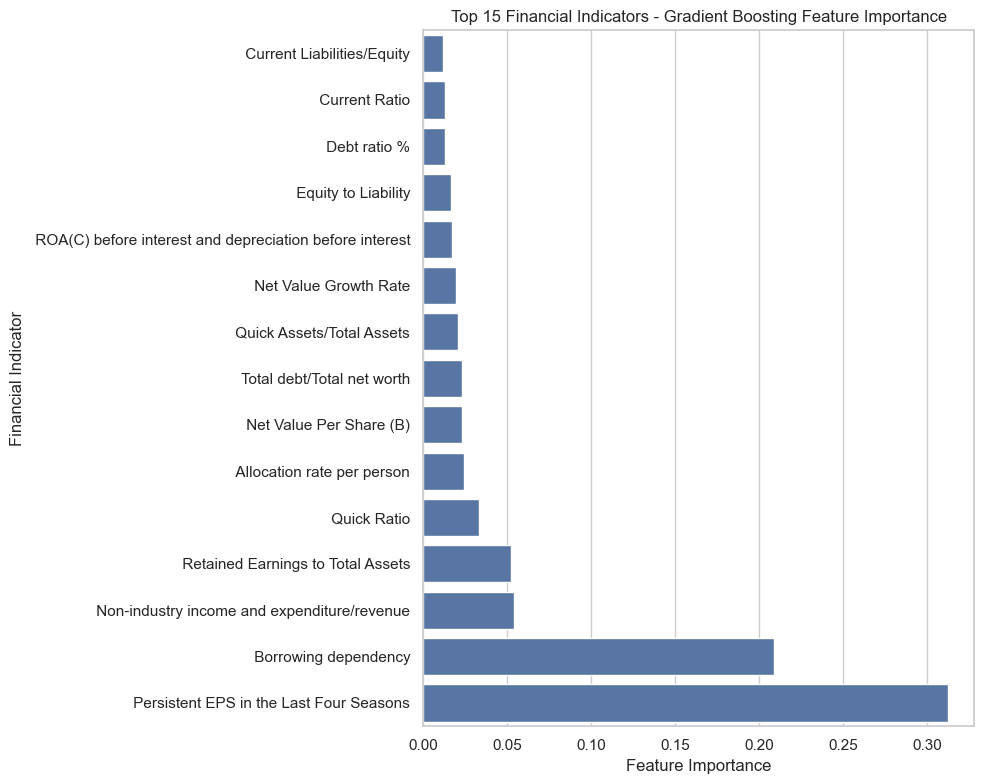

In [78]:
top_gb_features = gb_importance.head(15).sort_values(
    "Importance",
    ascending=True
)

plt.figure(figsize=(10, 8))

sns.barplot(
    data=top_gb_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Financial Indicators - Gradient Boosting Feature Importance")
plt.xlabel("Feature Importance")
plt.ylabel("Financial Indicator")
plt.tight_layout()
plt.show()

### Comparison of Tree-Based Feature Importance

Random Forest and Gradient Boosting use different ensemble learning strategies.

Comparing their feature importance rankings can help identify financial indicators that are repeatedly considered important by different models.

However, differences between the rankings are expected because each algorithm learns patterns differently.

In [79]:
feature_importance_comparison = pd.DataFrame({
    "Feature": X_train_selected.columns,
    "Random Forest Importance": rf_tuned_model.feature_importances_,
    "Gradient Boosting Importance": gb_tuned_model.feature_importances_
})

feature_importance_comparison["Average Importance"] = (
    feature_importance_comparison["Random Forest Importance"] +
    feature_importance_comparison["Gradient Boosting Importance"]
) / 2

feature_importance_comparison = feature_importance_comparison.sort_values(
    "Average Importance",
    ascending=False
).reset_index(drop=True)

display(feature_importance_comparison.head(20))

,Feature,Random Forest Importance,Gradient Boosting Importance,Average Importance
0,Persistent EPS in the Last Four Seasons,0.071131,0.312481,0.191806
1,Borrowing dependency,0.062557,0.208890,0.135723
2,Non-industry income and expenditure/revenue,0.037434,0.054277,0.045855
3,Retained Earnings to Total Assets,0.034351,0.052341,0.043346
4,Total debt/Total net worth,0.054036,0.022945,0.038491
5,Equity to Liability,0.053992,0.016494,0.035243
6,Net Income to Stockholder's Equity,0.064704,0.000554,0.032629
7,Net Value Per Share (B),0.036374,0.023024,0.029699
8,Quick Ratio,0.025614,0.032971,0.029293
9,ROA(C) before interest and depreciation befor...,0.034496,0.017031,0.025764


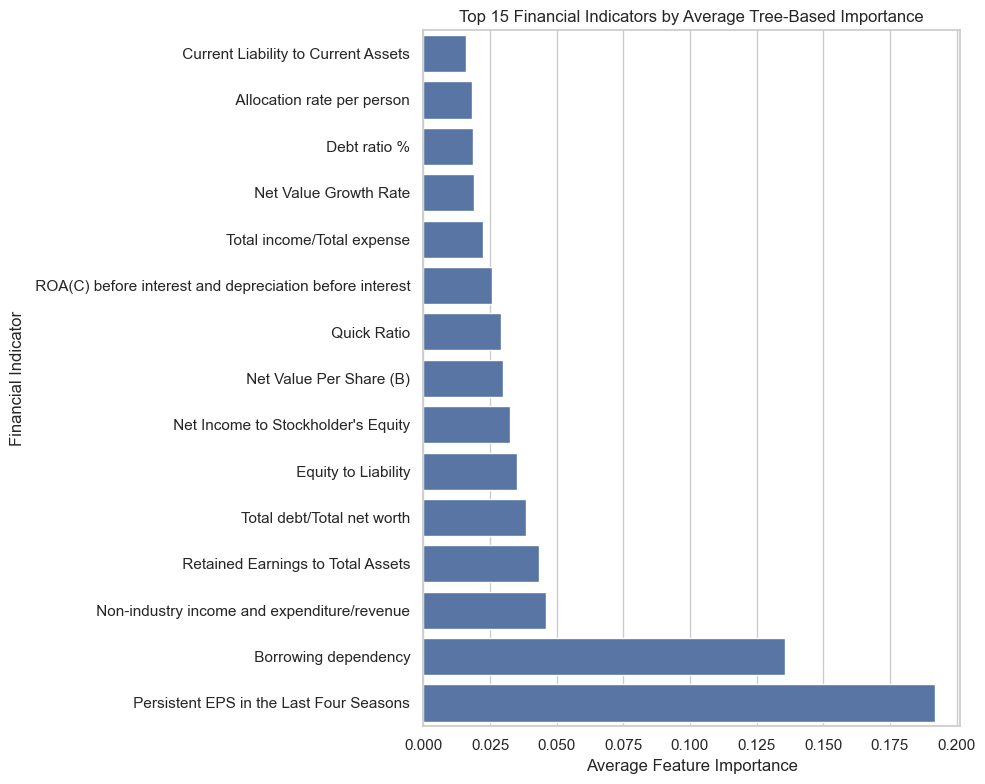

In [80]:
top_combined_features = feature_importance_comparison.head(15).sort_values(
    "Average Importance",
    ascending=True
)

plt.figure(figsize=(10, 8))

sns.barplot(
    data=top_combined_features,
    x="Average Importance",
    y="Feature"
)

plt.title("Top 15 Financial Indicators by Average Tree-Based Importance")
plt.xlabel("Average Feature Importance")
plt.ylabel("Financial Indicator")
plt.tight_layout()
plt.show()

### Important Financial Indicators

The feature importance analysis identifies the financial indicators that contribute most strongly to the predictions of the tree-based models.

These indicators can be compared with the earlier correlation analysis to determine whether variables showing strong statistical association with bankruptcy also appear among the important model features.

Correlation measures association with the target, whereas model-based feature importance measures the contribution of a feature within a particular machine learning model. Therefore, the two analyses may produce different rankings.

In [81]:
top_features = feature_importance_comparison.head(15)[
    ["Feature", "Random Forest Importance", 
     "Gradient Boosting Importance", "Average Importance"]
]

display(top_features.round(6))

,Feature,Random Forest Importance,Gradient Boosting Importance,Average Importance
0,Persistent EPS in the Last Four Seasons,0.071131,0.312481,0.191806
1,Borrowing dependency,0.062557,0.208890,0.135723
2,Non-industry income and expenditure/revenue,0.037434,0.054277,0.045855
3,Retained Earnings to Total Assets,0.034351,0.052341,0.043346
4,Total debt/Total net worth,0.054036,0.022945,0.038491
5,Equity to Liability,0.053992,0.016494,0.035243
6,Net Income to Stockholder's Equity,0.064704,0.000554,0.032629
7,Net Value Per Share (B),0.036374,0.023024,0.029699
8,Quick Ratio,0.025614,0.032971,0.029293
9,ROA(C) before interest and depreciation befor...,0.034496,0.017031,0.025764


### Explainability Consideration

Feature importance provides useful information about which variables the models rely on most heavily.

However, feature importance does not establish that a financial indicator causes bankruptcy. Highly correlated variables can also influence importance values, and the interpretation is specific to the model and dataset used in this project.

Therefore, the identified indicators should be considered as predictive signals rather than direct causal factors.

## 23. Error Analysis

Model performance should not be evaluated only using aggregate metrics such as accuracy and F1-score.

Error analysis helps identify the types of mistakes made by the final candidate models.

For bankruptcy prediction, two types of errors are particularly important:

- False Positive: A non-bankrupt company is predicted as bankrupt.
- False Negative: A bankrupt company is predicted as non-bankrupt.

False negatives may be particularly important in risk-screening applications because a potentially bankrupt company may not be flagged for further investigation.

### False Positive and False Negative Analysis

The following analysis will examine the predictions of the tuned Random Forest model.

The purpose is to understand how many companies were correctly and incorrectly classified and to identify the financial characteristics of misclassified companies.

In [83]:
final_candidate_model = best_models["Tuned Random Forest"]

final_candidate_pred = final_candidate_model.predict(X_test_selected)

error_analysis_df = X_test_selected.copy()
error_analysis_df["Actual"] = y_test.values
error_analysis_df["Predicted"] = final_candidate_pred

error_analysis_df["Prediction_Type"] = np.select(
    [
        (error_analysis_df["Actual"] == 0) & (error_analysis_df["Predicted"] == 0),
        (error_analysis_df["Actual"] == 0) & (error_analysis_df["Predicted"] == 1),
        (error_analysis_df["Actual"] == 1) & (error_analysis_df["Predicted"] == 0),
        (error_analysis_df["Actual"] == 1) & (error_analysis_df["Predicted"] == 1)
    ],
    [
        "True Negative",
        "False Positive",
        "False Negative",
        "True Positive"
    ],
    default="Other"
)

display(
    error_analysis_df["Prediction_Type"]
    .value_counts()
    .to_frame(name="Count")
)

,Count
Prediction_Type,
True Negative,1152
False Positive,168
True Positive,38
False Negative,6


### Error Distribution

The distribution below shows the number of true positives, true negatives, false positives, and false negatives produced by the tuned Random Forest model.

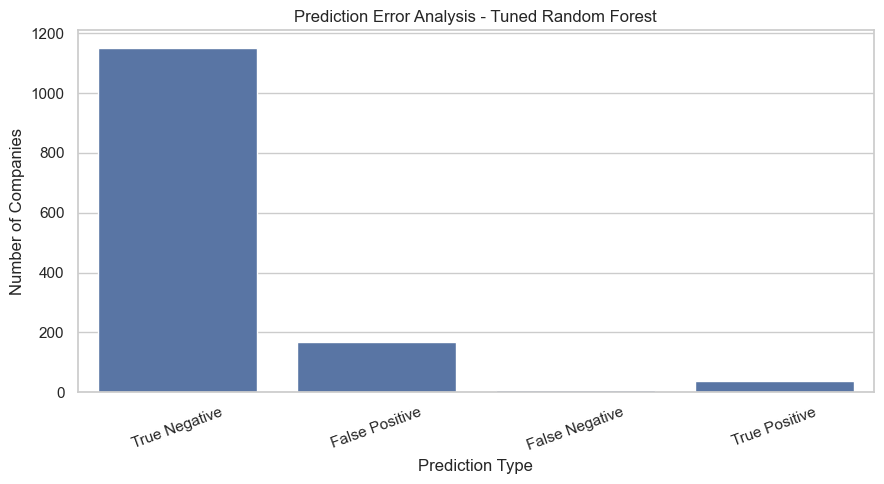

In [84]:
error_counts = (
    error_analysis_df["Prediction_Type"]
    .value_counts()
    .reindex([
        "True Negative",
        "False Positive",
        "False Negative",
        "True Positive"
    ])
    .fillna(0)
)

plt.figure(figsize=(9, 5))

sns.barplot(
    x=error_counts.index,
    y=error_counts.values
)

plt.title("Prediction Error Analysis - Tuned Random Forest")
plt.xlabel("Prediction Type")
plt.ylabel("Number of Companies")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### False Positive Analysis

False positives represent companies that were actually classified as non-bankrupt but were predicted by the model as bankrupt.

These predictions may lead to additional financial investigation or risk assessment for companies that are not classified as bankrupt.

In [85]:
false_positives = error_analysis_df[
    error_analysis_df["Prediction_Type"] == "False Positive"
]

print("Number of False Positives:", len(false_positives))

display(false_positives.head(10))

Number of False Positives: 168


,ROA(C) before interest and depreciation before interest,Operating Gross Margin,Operating Profit Rate,Non-industry income and expenditure/revenue,Operating Expense Rate,Research and development expense rate,Cash flow rate,Interest-bearing debt interest rate,Tax rate (A),Net Value Per Share (B),Persistent EPS in the Last Four Seasons,Cash Flow Per Share,Revenue Per Share (Yuan ¥),Operating Profit Per Share (Yuan ¥),Realized Sales Gross Profit Growth Rate,Operating Profit Growth Rate,After-tax Net Profit Growth Rate,Continuous Net Profit Growth Rate,Total Asset Growth Rate,Net Value Growth Rate,Cash Reinvestment %,Current Ratio,Quick Ratio,Interest Expense Ratio,Total debt/Total net worth,Debt ratio %,Long-term fund suitability ratio (A),Borrowing dependency,Contingent liabilities/Net worth,Inventory and accounts receivable/Net value,Total Asset Turnover,Accounts Receivable Turnover,Average Collection Days,Inventory Turnover Rate (times),Fixed Assets Turnover Frequency,Net Worth Turnover Rate (times),Revenue per person,Operating profit per person,Allocation rate per person,Working Capital to Total Assets,Quick Assets/Total Assets,Current Assets/Total Assets,Cash/Total Assets,Quick Assets/Current Liability,Cash/Current Liability,Current Liability to Assets,Operating Funds to Liability,Inventory/Working Capital,Inventory/Current Liability,Current Liabilities/Liability,Working Capital/Equity,Current Liabilities/Equity,Long-term Liability to Current Assets,Retained Earnings to Total Assets,Total income/Total expense,Total expense/Assets,Current Asset Turnover Rate,Quick Asset Turnover Rate,Cash Turnover Rate,Fixed Assets to Assets,Equity to Long-term Liability,Cash Flow to Total Assets,Cash Flow to Liability,CFO to Assets,Cash Flow to Equity,Current Liability to Current Assets,Liability-Assets Flag,Total assets to GNP price,No-credit Interval,Net Income to Stockholder's Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Equity to Liability,Actual,Predicted,Prediction_Type
3255,0.442695,0.596780,0.998849,0.303342,1.699856e-04,1.331117e-04,0.458019,4.890489e-04,0.000000,0.183937,0.194479,0.311417,0.021175,0.084195,0.021995,0.846588,0.687583,0.217405,6.050000e+09,0.000416,0.369072,0.010811,0.004817,0.629494,0.009390,0.150044,0.005834,0.378954,0.005366,0.405045,0.071964,0.000909,0.006959,3.250000e+08,2.171149e-04,0.024032,0.035345,0.378768,0.021096,0.815698,0.257690,0.536078,0.110975,0.005031,0.006303,0.093149,0.334657,0.277583,0.015273,0.585895,0.737369,0.331160,0.011943,0.924215,0.002062,0.023857,0.000292,1.407228e-04,1.629230e-04,0.177386,0.123164,0.620411,0.455448,0.535478,0.310313,0.027034,0,0.007504,0.623480,0.837843,0.026553,0.563692,0.024245,0,1,False Positive
3758,0.473115,0.584874,0.998620,0.303423,2.091864e-04,1.757279e-04,0.464296,3.540354e-04,0.000000,0.169525,0.194006,0.320153,0.009060,0.080775,0.021736,0.847951,0.689336,0.217585,4.560000e+09,0.000383,0.379149,0.005543,0.003777,0.630107,0.008237,0.140309,0.005044,0.378294,0.005655,0.395690,0.038981,0.001530,0.004132,1.041348e-04,3.560000e+09,0.016774,0.031820,0.355815,0.121168,0.746731,0.148161,0.194890,0.087194,0.004148,0.007007,0.065702,0.344552,0.275024,0.003956,0.437990,0.731619,0.329476,0.041384,0.920726,0.001897,0.016502,0.000174,1.363606e-04,2.118423e-04,0.683885,0.125717,0.575766,0.447094,0.582325,0.302666,0.051669,0,0.066851,0.623873,0.837210,0.026675,0.564537,0.026174,0,1,False Positive
6037,0.466631,0.597832,0.998931,0.303423,1.055761e-04,2.750000e+09,0.462139,3.550355e-04,0.000000,0.166744,0.204500,0.319622,0.027587,0.091442,0.021998,0.847890,0.688731,0.217524,6.950000e+09,0.000478,0.378693,0.007749,0.004644,0.629825,0.013705,0.177827,0.005198,0.378604,0.009166,0.405966,0.113943,0.000485,0.013022,1.918373e-04,1.762640e-04,0.040645,0.010076,0.390945,0.006884,0.787807,0.552207,0.598842,0.039406,0.006959,0.001454,0.143688,0.342399,0.277231,0.002394,0.769600,0.735759,0.335639,0.006033,0.923037,0.002109,0.022617,0.000214,2.0

### False Negative Analysis

False negatives represent companies that were classified as bankrupt but were predicted by the model as non-bankrupt.

These errors are particularly important to monitor because they represent bankrupt companies that were not identified by the model.

In [86]:
false_negatives = error_analysis_df[
    error_analysis_df["Prediction_Type"] == "False Negative"
]

print("Number of False Negatives:", len(false_negatives))

display(false_negatives.head(10))

Number of False Negatives: 6


,ROA(C) before interest and depreciation before interest,Operating Gross Margin,Operating Profit Rate,Non-industry income and expenditure/revenue,Operating Expense Rate,Research and development expense rate,Cash flow rate,Interest-bearing debt interest rate,Tax rate (A),Net Value Per Share (B),Persistent EPS in the Last Four Seasons,Cash Flow Per Share,Revenue Per Share (Yuan ¥),Operating Profit Per Share (Yuan ¥),Realized Sales Gross Profit Growth Rate,Operating Profit Growth Rate,After-tax Net Profit Growth Rate,Continuous Net Profit Growth Rate,Total Asset Growth Rate,Net Value Growth Rate,Cash Reinvestment %,Current Ratio,Quick Ratio,Interest Expense Ratio,Total debt/Total net worth,Debt ratio %,Long-term fund suitability ratio (A),Borrowing dependency,Contingent liabilities/Net worth,Inventory and accounts receivable/Net value,Total Asset Turnover,Accounts Receivable Turnover,Average Collection Days,Inventory Turnover Rate (times),Fixed Assets Turnover Frequency,Net Worth Turnover Rate (times),Revenue per person,Operating profit per person,Allocation rate per person,Working Capital to Total Assets,Quick Assets/Total Assets,Current Assets/Total Assets,Cash/Total Assets,Quick Assets/Current Liability,Cash/Current Liability,Current Liability to Assets,Operating Funds to Liability,Inventory/Working Capital,Inventory/Current Liability,Current Liabilities/Liability,Working Capital/Equity,Current Liabilities/Equity,Long-term Liability to Current Assets,Retained Earnings to Total Assets,Total income/Total expense,Total expense/Assets,Current Asset Turnover Rate,Quick Asset Turnover Rate,Cash Turnover Rate,Fixed Assets to Assets,Equity to Long-term Liability,Cash Flow to Total Assets,Cash Flow to Liability,CFO to Assets,Cash Flow to Equity,Current Liability to Current Assets,Liability-Assets Flag,Total assets to GNP price,No-credit Interval,Net Income to Stockholder's Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Equity to Liability,Actual,Predicted,Prediction_Type
233,0.469458,0.602091,0.999001,0.303452,1.032634e-04,0.000000e+00,0.464348,0.000739,0.000000,0.177953,0.216224,0.320011,0.009014,0.096898,0.022217,0.848401,0.689855,0.217640,7.460000e+09,0.000446,0.379271,0.004867,0.002152,0.636432,0.007370,0.132056,0.005046,0.377480,0.005423,0.396366,0.041979,0.001152,0.005491,7.910000e+09,3.250000e+09,0.016613,0.009350,0.393207,0.042055,0.742227,0.077033,0.138243,0.011382,0.002712,0.001124,0.053358,0.344074,0.275900,0.005918,0.375513,0.731298,0.328724,0.059387,0.931610,0.002318,0.007297,1.394958e-04,8.040000e+09,3.140000e+09,0.710598,0.125439,0.616598,0.454211,0.579259,0.310132,0.058460,0,0.007232,0.622374,0.840356,0.032780,0.569441,0.028018,1,0,False Negative
4375,0.473212,0.597746,0.998966,0.303543,7.040000e+09,1.460000e+09,0.454421,0.000367,0.000000,0.184611,0.215089,0.300453,0.047431,0.096328,0.022032,0.847937,0.689443,0.217572,5.890000e+09,0.000444,0.347137,0.004724,0.003845,0.632047,0.007608,0.134414,0.005679,0.376490,0.005758,0.401168,0.175412,0.000937,0.006752,2.697951e-04,5.484609e-04,0.044677,0.106749,0.393716,0.023803,0.726489,0.299633,0.355759,0.017461,0.003911,0.000672,0.137790,0.320294,0.276581,0.002457,0.973240,0.730098,0.332838,0.000302,0.938484,0.002282,0.018576,6.870000e+09,6.140000e+08,1.050000e+09,0.162322,0.111120,0.635583,0.457886,0.475735,0.313311,0.060135,0,0.006844,0.623280,0.840520,0.027616,0.567367,0.027471,1,0,False Negative
2704,0.495539,0.619770,0.999041,0.303521,3.479502e-04,0.000000e+00,0.456922,0.000961,0.313797,0.174203,0.216602,0.313999,0.006746,0.097712,0.022156,0.848126,0.689321,0.217589,8.130000e+09,0.000502,0.370329,0.018103,0.017396,0.632864,0.003421,0.080388,0.005987,0.372630,0.005366,0.401293,0.044978,0.000162,0.039106,2.841447e-03,1.112052e-04,0.015645,0.020017,0.397277,0.020990,0.868748,0.672400,0.646367,0.008724,0.018178,0.000682,0.067540,0.330144,0.276977,0.000159,0.780522,0.738638,0.328630,0.002739,0.932734,0.002266,0.019590,6.428862e-04,6.76

### Comparing Financial Indicators Across Prediction Groups

The average financial indicators for correctly and incorrectly classified companies can provide additional insight into the model's errors.

This analysis is descriptive and does not establish causal relationships.

In [87]:
prediction_group_means = (
    error_analysis_df
    .groupby("Prediction_Type")[X_test_selected.columns]
    .mean()
    .T
)

display(prediction_group_means.round(4))

Prediction_Type,False Negative,False Positive,True Negative,True Positive
ROA(C) before interest and depreciation before interest,4.754000e-01,4.391000e-01,5.215000e-01,4.136000e-01
Operating Gross Margin,6.082000e-01,6.013000e-01,6.101000e-01,5.972000e-01
Operating Profit Rate,9.990000e-01,9.962000e-01,9.990000e-01,9.985000e-01
Non-industry income and expenditure/revenue,3.034000e-01,3.013000e-01,3.037000e-01,3.021000e-01
Operating Expense Rate,2.780000e+09,1.864446e+09,2.090992e+09,2.190711e+09
Research and development expense rate,3.290000e+09,1.484899e+09,2.057937e+09,1.314526e+09
Cash flow rate,4.616000e-01,4.587000e-01,4.699000e-01,4.602000e-01
Interest-bearing debt interest rate,6.000000e-04,6.964286e+05,1.869878e+07,5.000000e-04
Tax rate (A),1.536000e-01,3.380000e-02,1.299000e-01,1.070000e-02
Net Value Per Share (B),1.902000e-01,1.664000e-01,1.983000e-01,1.551000e-01


### Error Analysis Interpretation

The error analysis highlights the distinction between overall model performance and individual prediction errors.

False negatives represent missed bankruptcy cases, while false positives represent companies that may receive additional risk attention despite being classified as non-bankrupt.

The acceptable balance between these two error types depends on the intended financial application and the relative cost of each type of error.

## 24. Model Risk and Limitations

Although machine learning can identify patterns associated with bankruptcy classification, the model has several limitations.

Potential limitations include:

1. Class imbalance may affect model learning and evaluation.
2. Random undersampling can remove information from the majority class.
3. Financial indicators may contain correlated information.
4. Historical relationships may not remain stable over time.
5. The dataset may not represent every industry or economic environment.
6. Model predictions do not establish causal relationships.
7. False positives and false negatives can both have financial consequences.
8. The model should not be used as the sole basis for lending or investment decisions.

These limitations should be considered before applying the model in a real-world environment.

### Production Considerations

For real-world deployment, the model should be monitored regularly for changes in data distributions and prediction performance.

A production system should also:

- Preserve the exact preprocessing and feature-selection steps used during training.
- Load the validated model rather than retraining it inside the application.
- Version the model and dependencies.
- Monitor prediction errors and data drift.
- Periodically evaluate the model using genuinely new financial data.
- Provide appropriate human review for high-impact financial decisions.

## 25. Key Project Questions

The project was designed to answer three main questions:

1. Which financial indicators are the most significant predictors of bankruptcy?
2. How does model performance compare across different machine learning algorithms?
3. What are the potential risks and limitations of using the model in real-world decision-making?

The following sections summarize the findings from the analysis performed in this notebook.

### Question 1: Which Financial Indicators Are the Most Significant Predictors of Bankruptcy?

The feature importance analysis identified the financial indicators that contributed most strongly to the predictions of the tree-based models.

The Random Forest and Gradient Boosting feature importance results were compared to identify indicators that consistently appeared among the important model features.

Earlier correlation analysis was also used to identify financial indicators that showed stronger statistical associations with the bankruptcy target.

These results should be interpreted as predictive relationships rather than causal relationships.

In [88]:
print("Top 10 Financial Indicators Based on Average Tree-Based Importance:")

display(
    feature_importance_comparison.head(10).round(6)
)

Top 10 Financial Indicators Based on Average Tree-Based Importance:


,Feature,Random Forest Importance,Gradient Boosting Importance,Average Importance
0,Persistent EPS in the Last Four Seasons,0.071131,0.312481,0.191806
1,Borrowing dependency,0.062557,0.208890,0.135723
2,Non-industry income and expenditure/revenue,0.037434,0.054277,0.045855
3,Retained Earnings to Total Assets,0.034351,0.052341,0.043346
4,Total debt/Total net worth,0.054036,0.022945,0.038491
5,Equity to Liability,0.053992,0.016494,0.035243
6,Net Income to Stockholder's Equity,0.064704,0.000554,0.032629
7,Net Value Per Share (B),0.036374,0.023024,0.029699
8,Quick Ratio,0.025614,0.032971,0.029293
9,ROA(C) before interest and depreciation befor...,0.034496,0.017031,0.025764


### Question 2: How Does Model Performance Compare Across Different Algorithms?

The project evaluated Logistic Regression, Decision Tree, Random Forest, and Gradient Boosting models.

Hard Voting and Soft Voting classifiers were also evaluated as ensemble approaches.

Hyperparameter optimization was subsequently performed for the individual classification algorithms using cross-validation and F1-score as the optimization metric.

The comparison should consider precision, recall, F1-score and ROC-AUC in addition to accuracy because the dataset contains a substantial class imbalance.

In [89]:
print("Initial Model Performance:")
display(results_df.round(4))

print("\nTuned Model Performance:")
display(tuned_results_df.round(4))

print("\nVoting Model Performance:")
display(
    pd.concat(
        [voting_results, soft_voting_results],
        ignore_index=True
    ).round(4)
)

Initial Model Performance:


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.6935,0.0483,0.4545,0.0873,0.6395
1,Decision Tree,0.8152,0.1176,0.7273,0.2025,0.7727
2,Random Forest,0.8710,0.1827,0.8636,0.3016,0.9455
3,Gradient Boosting,0.8710,0.1827,0.8636,0.3016,0.9453



Tuned Model Performance:


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Tuned Logistic Regression,0.6957,0.0487,0.4545,0.0879,0.6408
1,Tuned Decision Tree,0.8541,0.1556,0.7955,0.2602,0.8550
2,Tuned Random Forest,0.8724,0.1845,0.8636,0.3040,0.9451
3,Tuned Gradient Boosting,0.8607,0.1741,0.8864,0.2910,0.9447



Voting Model Performance:


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Hard Voting Classifier,0.8930,0.1964,0.7500,0.3113,NaN
1,Soft Voting Classifier,0.8548,0.1562,0.7955,0.2612,0.9256


### Question 3: What Are the Potential Risks of Using the Model in Real-World Decision-Making?

The model has several potential risks and limitations.

First, the dataset is highly imbalanced, meaning that bankrupt companies represent a much smaller proportion of observations than non-bankrupt companies.

Second, random undersampling was used to balance the training data. Although this helps address class imbalance, it can remove information from the majority class.

Third, financial indicators can be correlated with one another, which may affect model interpretation and feature importance.

Fourth, historical financial relationships may change over time because of changes in economic conditions, industries, regulations, and financial markets.

Finally, prediction errors can have financial consequences. Therefore, model predictions should be used as decision-support information rather than as the sole basis for lending, investment, or other high-impact financial decisions.

## 26. Business Insights

The analysis provides several business-oriented insights:

### 1. Financial Health Indicators
Profitability, leverage, liquidity, and other financial indicators can provide useful signals for distinguishing between bankrupt and non-bankrupt companies.

### 2. Early Risk Identification
A bankruptcy prediction model can be used as an initial screening mechanism to identify companies that may require additional financial analysis.

### 3. Importance of Multiple Indicators
Bankruptcy risk should not be evaluated using a single financial ratio. Machine learning models can consider relationships across multiple financial indicators simultaneously.

### 4. Human Review
Model predictions should be combined with financial expertise, company-specific information, and other relevant evidence before making high-impact decisions.

## 27. Final Model Evaluation Considerations

The final model should be assessed using multiple performance measures rather than accuracy alone.

Important measures include:

- Precision
- Recall
- F1-Score
- ROC-AUC
- Confusion Matrix

For bankruptcy prediction, recall is particularly relevant because false negatives represent bankrupt companies that were not identified by the model.

At the same time, precision is important because excessive false positives may result in unnecessary additional investigation.

## 28. Reproducibility and Production Considerations

To make the project reproducible and suitable for future deployment, the final trained model should be saved together with the exact feature-selection and preprocessing configuration used during model development.

The production application should load the validated model rather than retraining the model every time the application starts.

Model versions, dependencies, training data, feature definitions, and evaluation results should also be documented and version controlled.

## 29. Overall Project Conclusion

This project developed an end-to-end machine learning workflow for predicting company bankruptcy using financial indicators.

The workflow included:

- Dataset understanding
- Data quality analysis
- Exploratory data analysis
- Target distribution analysis
- Correlation analysis
- Feature selection
- Train-test splitting
- Class imbalance handling
- Multiple classification algorithms
- Ensemble modelling
- Hyperparameter optimization
- Model evaluation
- Feature importance analysis
- Error analysis
- Business interpretation

The analysis demonstrates how machine learning can be used to identify patterns in financial indicators associated with bankruptcy classification.

However, the model should be considered a decision-support system rather than a replacement for professional financial assessment.

## 30. Project Limitations

The main limitations of this project include:

1. The dataset contains a highly imbalanced target variable.
2. Random undersampling may result in loss of information from the majority class.
3. The analysis is based on historical financial data.
4. Correlated financial indicators may affect model interpretation.
5. Feature importance does not imply causation.
6. Model performance may change when applied to new companies, industries, or economic conditions.
7. The current evaluation does not fully replace validation using genuinely future financial observations.
8. Financial decisions based on model predictions require appropriate human oversight.

## 31. Future Improvements

Several improvements could strengthen the project further:

- Evaluate alternative class-imbalance techniques such as SMOTE and class-weighted models.
- Use cross-validation pipelines where resampling occurs separately inside each training fold.
- Investigate time-based validation using genuinely future observations where suitable data is available.
- Apply permutation importance or SHAP-based explainability.
- Monitor model performance and data drift after deployment.
- Incorporate additional financial and non-financial information where available.
- Compare model performance across different industries or company segments.
- Periodically retrain and validate the model using updated financial data.

# Final Conclusion

The company bankruptcy prediction project demonstrates a complete machine learning classification workflow using financial indicators.

The analysis combines exploratory data analysis, statistical relationships, machine learning classification, ensemble modelling, hyperparameter optimization, feature importance, and error analysis.

The results provide insights into financial indicators associated with bankruptcy classification and demonstrate how different machine learning approaches can be evaluated for financial risk assessment.

The model should ultimately be used as one component of a broader financial risk assessment process, supported by appropriate validation, monitoring, and human review.

## 32. Final Model Preparation

Before deployment, the selected model should be saved together with the information required to reproduce the same prediction workflow.

The saved model should use the same selected features that were used during model development.

The model will be stored using Joblib so that it can be loaded later without retraining.

In [90]:
import joblib
import os

print("Joblib imported successfully.")

Joblib imported successfully.


### Selected Features

The final model requires the same feature set that was used during training.

The selected feature names will therefore be saved separately so that future predictions use the correct columns and column order.

In [91]:
selected_feature_names = list(X_train_selected.columns)

print("Number of selected features:", len(selected_feature_names))
print("\nSelected features:")
print(selected_feature_names)

Number of selected features: 73

Selected features:
[' ROA(C) before interest and depreciation before interest', ' Operating Gross Margin', ' Operating Profit Rate', ' Non-industry income and expenditure/revenue', ' Operating Expense Rate', ' Research and development expense rate', ' Cash flow rate', ' Interest-bearing debt interest rate', ' Tax rate (A)', ' Net Value Per Share (B)', ' Persistent EPS in the Last Four Seasons', ' Cash Flow Per Share', ' Revenue Per Share (Yuan ¥)', ' Operating Profit Per Share (Yuan ¥)', ' Realized Sales Gross Profit Growth Rate', ' Operating Profit Growth Rate', ' After-tax Net Profit Growth Rate', ' Continuous Net Profit Growth Rate', ' Total Asset Growth Rate', ' Net Value Growth Rate', ' Cash Reinvestment %', ' Current Ratio', ' Quick Ratio', ' Interest Expense Ratio', ' Total debt/Total net worth', ' Debt ratio %', ' Long-term fund suitability ratio (A)', ' Borrowing dependency', ' Contingent liabilities/Net worth', ' Inventory and accounts receiva

### Model Saving Directory

A separate directory will be created to store the trained model and supporting configuration files.

In [92]:
model_dir = "../Models"

os.makedirs(model_dir, exist_ok=True)

print("Model directory is ready:", model_dir)

Model directory is ready: ../Models


### Saving the Candidate Model

For the current workflow, the tuned Random Forest model is saved as the candidate model.

The final model choice will be documented separately based on the complete model comparison.

In [93]:
model_path = os.path.join(
    model_dir,
    "tuned_random_forest_candidate.joblib"
)

joblib.dump(
    final_candidate_model,
    model_path
)

print("Candidate model saved successfully.")
print("Saved to:", model_path)

Candidate model saved successfully.
Saved to: ../Models\tuned_random_forest_candidate.joblib


### Saving the Selected Feature Configuration

The feature list is saved separately so that the deployment workflow can reproduce the same feature-selection step used during model training.

In [94]:
feature_path = os.path.join(
    model_dir,
    "selected_features.joblib"
)

joblib.dump(
    selected_feature_names,
    feature_path
)

print("Selected feature configuration saved successfully.")
print("Saved to:", feature_path)

Selected feature configuration saved successfully.
Saved to: ../Models\selected_features.joblib


In [95]:
print("Model file exists:", os.path.exists(model_path))
print("Feature file exists:", os.path.exists(feature_path))

Model file exists: True
Feature file exists: True


## 33. Final Candidate Model Evaluation

The candidate model will be evaluated using threshold-based performance curves in addition to the previously calculated classification metrics.

ROC-AUC provides an overall measure of discrimination across classification thresholds, while the Precision-Recall curve is particularly informative for imbalanced classification problems.

In [96]:
from sklearn.metrics import roc_curve, precision_recall_curve, auc

candidate_prob = final_candidate_model.predict_proba(
    X_test_selected
)[:, 1]

fpr, tpr, roc_thresholds = roc_curve(
    y_test,
    candidate_prob
)

precision_curve, recall_curve, pr_thresholds = precision_recall_curve(
    y_test,
    candidate_prob
)

roc_auc = auc(fpr, tpr)
pr_auc = auc(recall_curve, precision_curve)

print("ROC-AUC:", round(roc_auc, 4))
print("PR-AUC:", round(pr_auc, 4))

ROC-AUC: 0.9451
PR-AUC: 0.3871


### ROC Curve

The ROC curve shows the relationship between the True Positive Rate and False Positive Rate across different classification thresholds.

A larger area under the ROC curve indicates stronger discrimination between the two target classes.

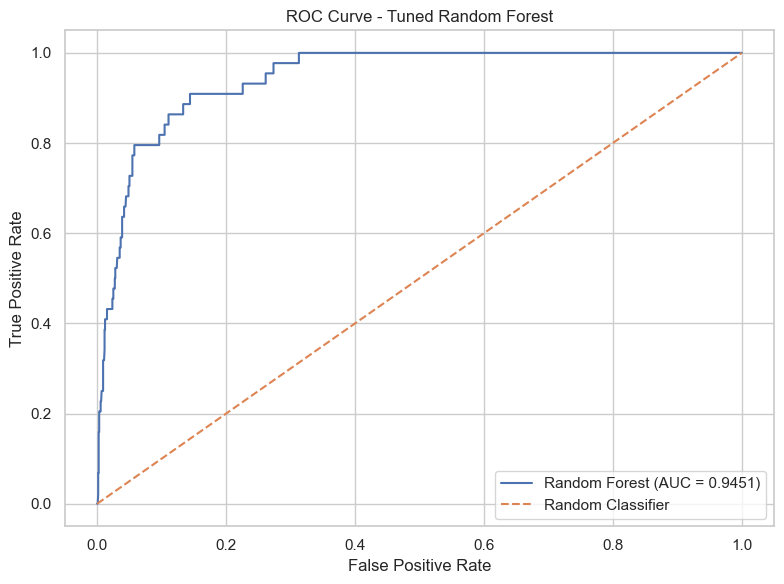

In [97]:
plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Random Forest (AUC = {roc_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.title("ROC Curve - Tuned Random Forest")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

### Precision-Recall Curve

The Precision-Recall curve shows the trade-off between precision and recall across different classification thresholds.

Because the bankruptcy class represents a small proportion of the dataset, Precision-Recall analysis provides useful additional information about the model's ability to identify bankrupt companies.

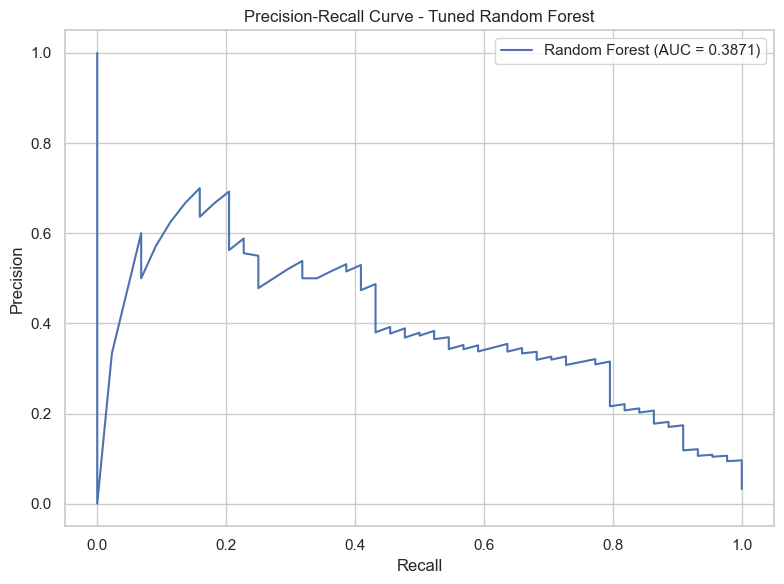

In [98]:
plt.figure(figsize=(8, 6))

plt.plot(
    recall_curve,
    precision_curve,
    label=f"Random Forest (AUC = {pr_auc:.4f})"
)

plt.title("Precision-Recall Curve - Tuned Random Forest")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.tight_layout()
plt.show()

## 34. Saved Model Verification

The saved candidate model will now be loaded from disk to verify that the serialized model produces the same predictions as the model currently stored in memory.

This step improves reproducibility and confirms that the saved model can be used without retraining.

In [99]:
loaded_model = joblib.load(model_path)

print("Saved model loaded successfully.")
print(loaded_model)

Saved model loaded successfully.
RandomForestClassifier(min_samples_leaf=2, n_jobs=-1, random_state=42)


In [100]:
loaded_predictions = loaded_model.predict(
    X_test_selected
)

predictions_match = np.array_equal(
    final_candidate_pred,
    loaded_predictions
)

print("Do original and loaded model predictions match?")
print(predictions_match)

Do original and loaded model predictions match?
True


### Model Reproducibility Check

If the original and loaded model predictions match, the serialized model successfully reproduces the predictions generated by the trained model.

This confirms that the model can be loaded for future use without retraining it.

## 35. Final Candidate Model Metrics

The final candidate model metrics are summarized below for convenient reference.

In [101]:
candidate_metrics = evaluate_model(
    final_candidate_model,
    X_test_selected,
    y_test
)

candidate_metrics_df = pd.DataFrame({
    "Metric": candidate_metrics.keys(),
    "Score": candidate_metrics.values()
})

display(candidate_metrics_df.round(4))

,Metric,Score
0,Accuracy,0.8724
1,Precision,0.1845
2,Recall,0.8636
3,F1-Score,0.3040
4,ROC-AUC,0.9451


## Final Evaluation Note

The candidate model has been evaluated using classification metrics, ROC-AUC, Precision-Recall analysis, and confusion matrix analysis.

The serialized model was also loaded and tested to verify reproducibility.

The final model selection should be documented using the complete comparison of baseline models, tuned models, and ensemble models rather than relying on a single performance metric.

## 36. Comprehensive Model Comparison

The final comparison combines the performance of the baseline models, tuned models, and voting classifiers.

This comparison provides a consolidated view of the different approaches evaluated during the project.

In [102]:
all_model_results = pd.concat(
    [
        results_df,
        tuned_results_df,
        voting_results,
        soft_voting_results
    ],
    ignore_index=True,
    sort=False
)

display(
    all_model_results.round(4)
)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.6935,0.0483,0.4545,0.0873,0.6395
1,Decision Tree,0.8152,0.1176,0.7273,0.2025,0.7727
2,Random Forest,0.8710,0.1827,0.8636,0.3016,0.9455
3,Gradient Boosting,0.8710,0.1827,0.8636,0.3016,0.9453
4,Tuned Logistic Regression,0.6957,0.0487,0.4545,0.0879,0.6408
5,Tuned Decision Tree,0.8541,0.1556,0.7955,0.2602,0.8550
6,Tuned Random Forest,0.8724,0.1845,0.8636,0.3040,0.9451
7,Tuned Gradient Boosting,0.8607,0.1741,0.8864,0.2910,0.9447
8,Hard Voting Classifier,0.8930,0.1964,0.7500,0.3113,NaN
9,Soft Voting Classifier,0.8548,0.1562,0.7955,0.2612,0.9256


### Performance Comparison

The table above summarizes the performance of all evaluated models.

Accuracy provides an overall measure of correct classification, while precision, recall and F1-score provide more detailed information about the model's performance on the classification task.

ROC-AUC is available for models that provide probability estimates.

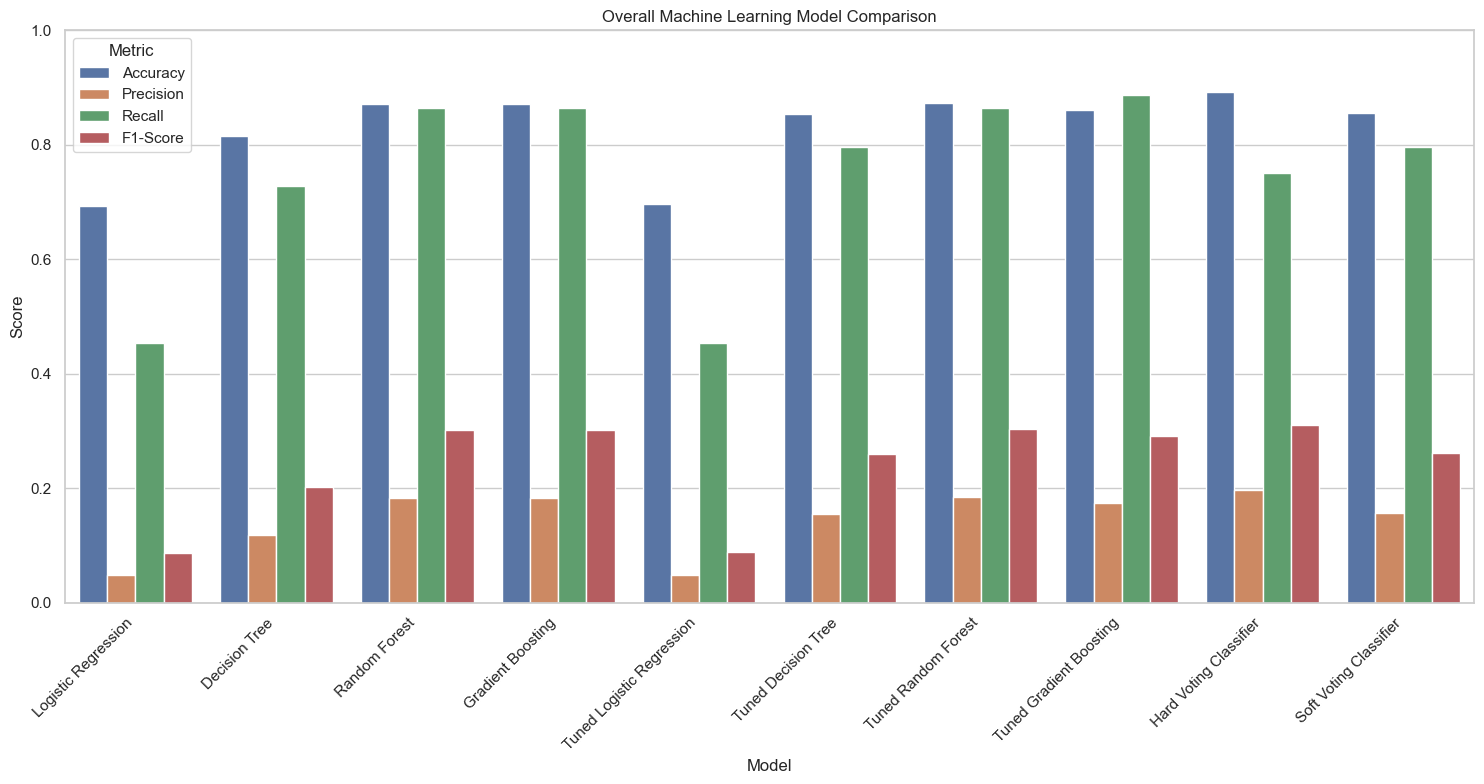

In [103]:
comparison_metrics = all_model_results.melt(
    id_vars="Model",
    value_vars=["Accuracy", "Precision", "Recall", "F1-Score"],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(15, 8))

sns.barplot(
    data=comparison_metrics,
    x="Model",
    y="Score",
    hue="Metric"
)

plt.title("Overall Machine Learning Model Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

## 37. Model Comparison Summary

The model comparison demonstrates that different algorithms produce different balances between precision, recall and F1-score.

Because bankruptcy prediction involves an imbalanced target variable, model evaluation should focus on multiple metrics rather than accuracy alone.

The final model choice should therefore be documented based on the complete evaluation results and the intended financial risk-management objective.

## 38. Key Findings Summary

The major findings from the project can be summarized as follows:

- The dataset contains a highly imbalanced bankruptcy target.
- Exploratory analysis identified meaningful relationships between several financial indicators and bankruptcy classification.
- Highly correlated predictor variables were identified during correlation analysis.
- Feature selection was performed using the training data.
- Random undersampling was applied only to the training data to address class imbalance.
- Multiple classification algorithms were evaluated.
- Voting classifiers were tested as ensemble approaches.
- Hyperparameter optimization was performed using cross-validation and F1-score.
- Tree-based feature importance was used to identify influential financial indicators.
- Error analysis examined false positive and false negative predictions.
- Model serialization and loading were tested for reproducibility.

## 39. Answers to the Key Business Questions

### 1. Which financial indicators are the most significant predictors of bankruptcy?

The feature importance analysis identified the financial indicators that contributed most strongly to the tree-based model predictions.

The detailed ranking is provided in the feature importance tables and visualizations in this notebook.

These indicators should be interpreted as predictive signals rather than causal factors.

### 2. How does model performance compare across different machine learning algorithms?

The project evaluated Logistic Regression, Decision Tree, Random Forest, Gradient Boosting, and Voting Classifier approaches.

Performance was compared using accuracy, precision, recall, F1-score and ROC-AUC where applicable.

The complete comparison is presented in the final model comparison table.

### 3. What are the potential risks of using the model in real-world decision-making?

Important risks include class imbalance, information loss caused by undersampling, correlated predictors, changing financial conditions, prediction errors, data drift, and differences between historical data and future observations.

The model should therefore support, rather than replace, appropriate financial analysis and human review.

## 40. Project Deliverables

The completed project includes:

1. Exploratory Data Analysis
2. Data quality assessment
3. Feature selection
4. Class imbalance handling
5. Multiple machine learning classification models
6. Voting Classifier
7. Hyperparameter optimization
8. Model performance comparison
9. Confusion matrix analysis
10. Feature importance analysis
11. Error analysis
12. Business insights
13. Model limitations and risks
14. Serialized model for reproducibility

## 41. Final Project Statement

This project demonstrates an end-to-end machine learning approach for predicting company bankruptcy using financial indicators.

The workflow combines data analysis, feature selection, class imbalance handling, machine learning, ensemble modelling, hyperparameter optimization, explainability, error analysis, and reproducibility.

The resulting analysis provides a structured framework for using financial data to support bankruptcy risk assessment while recognizing the limitations and risks associated with predictive modelling.

In [104]:
print("=" * 70)
print("PROJECT COMPLETION SUMMARY")
print("=" * 70)

print("Dataset shape:", df.shape)
print("Number of original predictors:", df.shape[1] - 1)
print("Number of selected predictors:", X_train_selected.shape[1])
print("Training observations after undersampling:", X_train_resampled.shape[0])
print("Testing observations:", X_test_selected.shape[0])
print("Number of baseline models:", len(models))
print("Number of tuned models:", len(best_models))
print("Model file saved:", os.path.exists(model_path))
print("Feature configuration saved:", os.path.exists(feature_path))

PROJECT COMPLETION SUMMARY
Dataset shape: (6819, 96)
Number of original predictors: 95
Number of selected predictors: 73
Training observations after undersampling: 352
Testing observations: 1364
Number of baseline models: 4
Number of tuned models: 4
Model file saved: True
Feature configuration saved: True


## 42. End of Notebook

This notebook documents the complete machine learning workflow used for company bankruptcy prediction.

All major stages, from data understanding through model evaluation and reproducibility, have been documented to support transparent analysis and future deployment.

In [105]:
print("Company Bankruptcy Prediction Project completed successfully.")

Company Bankruptcy Prediction Project completed successfully.


In [106]:
print("=" * 70)
print("FINAL PROJECT VERIFICATION")
print("=" * 70)

print("\nDataset:")
print("Shape:", df.shape)
print("Target:", "Bankrupt?")

print("\nData Quality:")
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
print("Constant features removed:", constant_features)

print("\nFeature Selection:")
print("Original predictors:", df.shape[1] - 1)
print("Selected predictors:", X_train_selected.shape[1])

print("\nClass Imbalance:")
print("Original bankrupt companies:", int(y.sum()))
print("Original non-bankrupt companies:", int((y == 0).sum()))
print("Resampled training size:", len(y_train_resampled))

print("\nModels:")
print("Baseline models:", list(models.keys()))
print("Tuned models:", list(best_models.keys()))

print("\nSaved Files:")
print("Model exists:", os.path.exists(model_path))
print("Feature file exists:", os.path.exists(feature_path))

print("\n" + "=" * 70)
print("VERIFICATION COMPLETE")
print("=" * 70)

FINAL PROJECT VERIFICATION

Dataset:
Shape: (6819, 96)
Target: Bankrupt?

Data Quality:
Missing values: 0
Duplicate rows: 0
Constant features removed: [' Net Income Flag']

Feature Selection:
Original predictors: 95
Selected predictors: 73

Class Imbalance:
Original bankrupt companies: 220
Original non-bankrupt companies: 6599
Resampled training size: 352

Models:
Baseline models: ['Logistic Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting']
Tuned models: ['Tuned Logistic Regression', 'Tuned Decision Tree', 'Tuned Random Forest', 'Tuned Gradient Boosting']

Saved Files:
Model exists: True
Feature file exists: True

VERIFICATION COMPLETE
